In [95]:
import pandas as pd
import os

path_data = 'C:/Users/skar/Box/_Saura_Self/Proj - Water tool analysis/data/output'
fname = 'survey_effluent_one.xlsx'
sname = 'Sheet1'

path_out = 'C:/Users/skar/Box/_Saura_Self/Proj - Water tool analysis/data/output'

df = pd.read_excel(os.path.join(path_data, fname), sheet_name=sname)

for col in df.columns:
    print(col)
df = df[['CWNS_ID', 
         'ACTUAL_FLOW_AVG', 
         'PREDICTED_WRRF_TT_CODE', 
         'Electricity_consumed_onsite_kWh_per_m3',
         'Electricity_purchased_from_utility_kWh_per_m3', 
         'NATURAL_GAS_PURCHASED_onsite_MJ_per_m3', 
         'Biogas_generated_onsite_MJ_per_m3', 
         'Electricity_produced_onsite_kWh_per_m3',
         'Total energy purchased_MJ_per_m3_survey',
         
         'BOD5_AVG_reduction',
            'CBOD5_AVG_reduction',
            'SS_AVG_reduction',
            'VSS_AVG_reduction',
            'TS_AVG_reduction',
            'TSS_AVG_reduction',
            'VTS_AVG_reduction',
            'TKN_AVG_reduction',
            'TN_AVG_reduction',
            'NH3_N_AVG_reduction',
            'NO3_N_AVG_reduction',
            'NO2_N_AVG_reduction',
            'NO3_N+NO2_N_AVG_reduction',
            'P_TOTAL_AVG_reduction',
            'P_SOLID_AVG_reduction',]]
#print(df.head())

CWNS_ID
FACILITY_ID
FACILITY_NAME
LATITUDE
LONGITUDE
CITY
STATE_CODE
AUTHORITY_NAME
COUNTY_NAME
DESIGN_FLOW
DESIGN_FLOW_UNITS
ACTUAL_FLOW_MIN
ACTUAL_FLOW_MAX
ACTUAL_FLOW_AVG
ACTUAL_FLOW_UNITS
PREDICTED_WRRF_TT_CODE
TT_IDENTIFIED
Assigned TT
BOD5_MIN
BOD5_MAX
BOD5_AVG
BOD5_UNITS
CBOD5_MIN
CBOD5_MAX
CBOD5_AVG
CBOD5_UNITS
SS_MIN
SS_MAX
SS_AVG
SS_UNITS
VSS_MIN
VSS_MAX
VSS_AVG
VSS_UNITS
TS_MIN
TS_MAX
TS_AVG
TS_UNITS
TSS_MIN
TSS_MAX
TSS_AVG
TSS_UNITS
VTS_MIN
VTS_MAX
VTS_AVG
VTS_UNITS
TKN_MIN
TKN_MAX
TKN_AVG
TKN_UNITS
TN_MIN
TN_MAX
TN_AVG
TN_UNITS
NH3_N_MIN
NH3_N_MAX
NH3_N_AVG
NH3_N_UNITS
NO3_N_MIN
NO3_N_MAX
NO3_N_AVG
NO3_N_UNITS
NO2_N_MIN
NO2_N_MAX
NO2_N_AVG
NO2_N_UNITS
NO3_N+NO2_N_MIN
NO3_N+NO2_N_MAX
NO3_N+NO2_N_AVG
NO3_N+NO2_N_UNITS
P_TOTAL_MIN
P_TOTAL_MAX
P_TOTAL_AVG
P_TOTAL_UNITS
P_SOLID_MIN
P_SOLID_MAX
P_SOLID_AVG
P_SOLID_UNITS
ELECTRICITY_CONSUMED_ONSITE__YEARLY_TOTAL
ELECTRICITY_CONSUMED_ONSITE_YEARLY_TOTAL_UNITS
Electricity_consumed_onsite_kWh_per_m3
ELECTRICITY_PURCHASED_FROM_UTILIT

Auto-renamed 22 columns from display_names.

Running analysis: VariableType.FLOW_METRICS vs VariableType.ENERGY_METRICS

CORRELATION ANALYSIS: VariableType.FLOW_METRICS vs VariableType.ENERGY_METRICS
Method: SPEARMAN
Variables in X: 1
Variables in Y: 6
Significance levels: (*** p<0.01, ** p<0.05, * p<0.1)
Minimum n required to compute correlation: 10

--------------------------------------------------------------------------------
DETAILED CORRELATION RESULTS WITH P-VALUES
--------------------------------------------------------------------------------

Total Electricity utilized (kWh/m3):
------------------------------------------------------------
  Actual Flow (MGD)             : r = -0.3082, p = 0.0762, n = 34 *

Electricity purchased (kWh/m3):
------------------------------------------------------------
  Actual Flow (MGD)             : r = -0.1817, p = 0.3038, n = 34 

Natural Gas purchased (MJ/m3):
------------------------------------------------------------
  Actual Flow (MGD) 

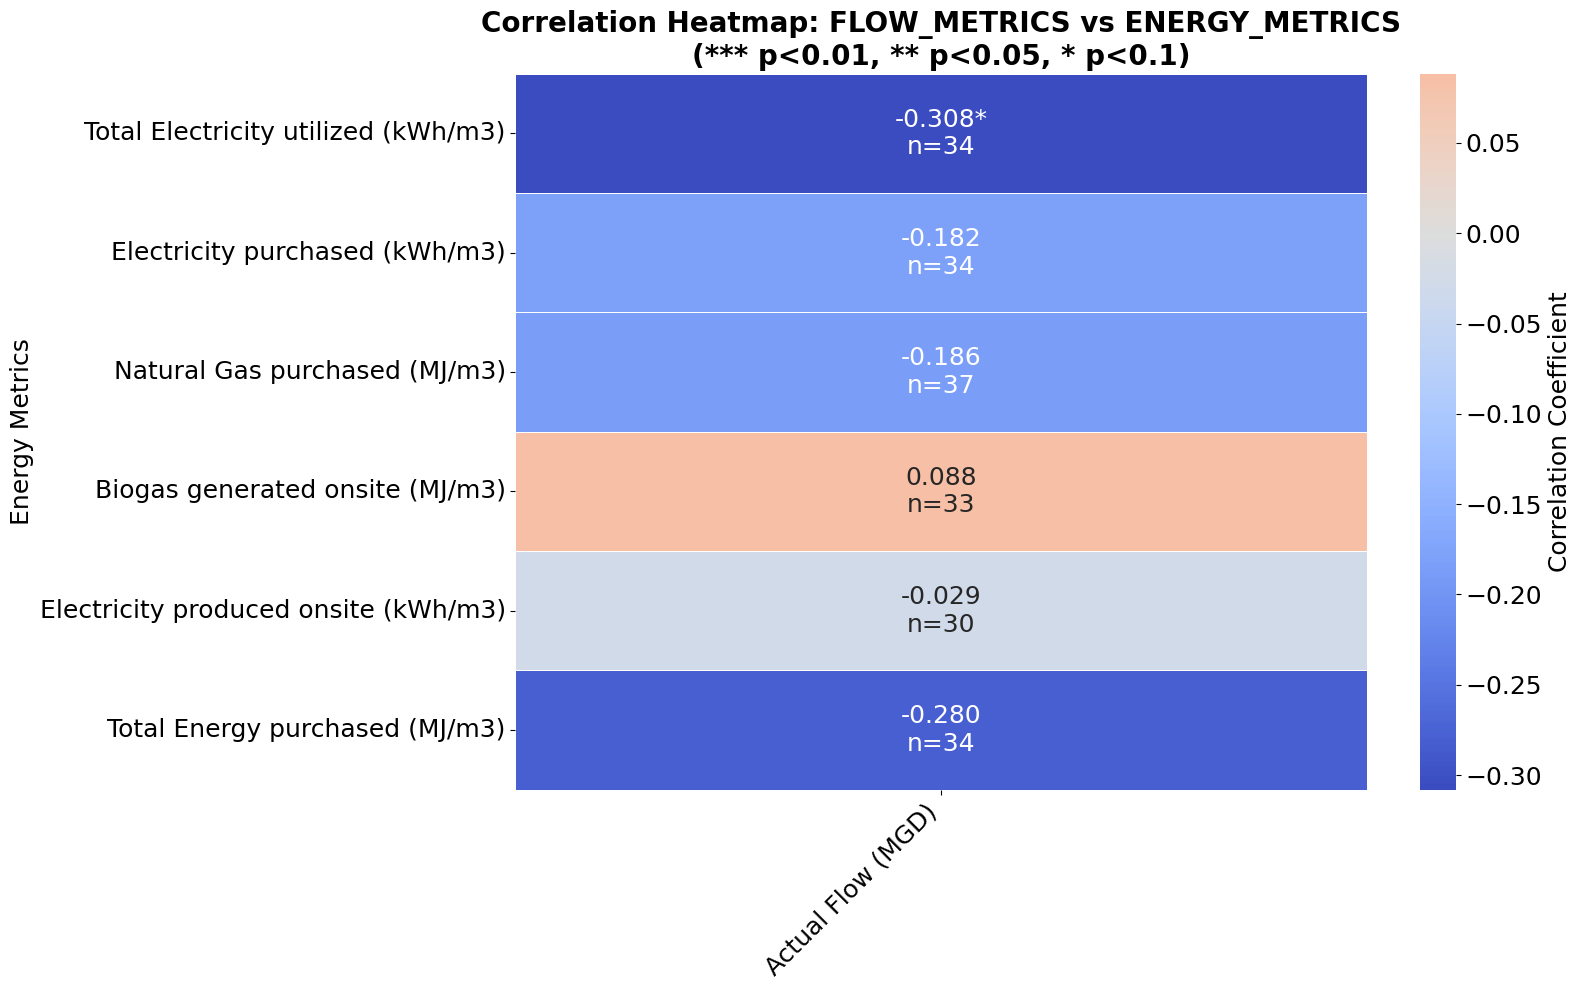

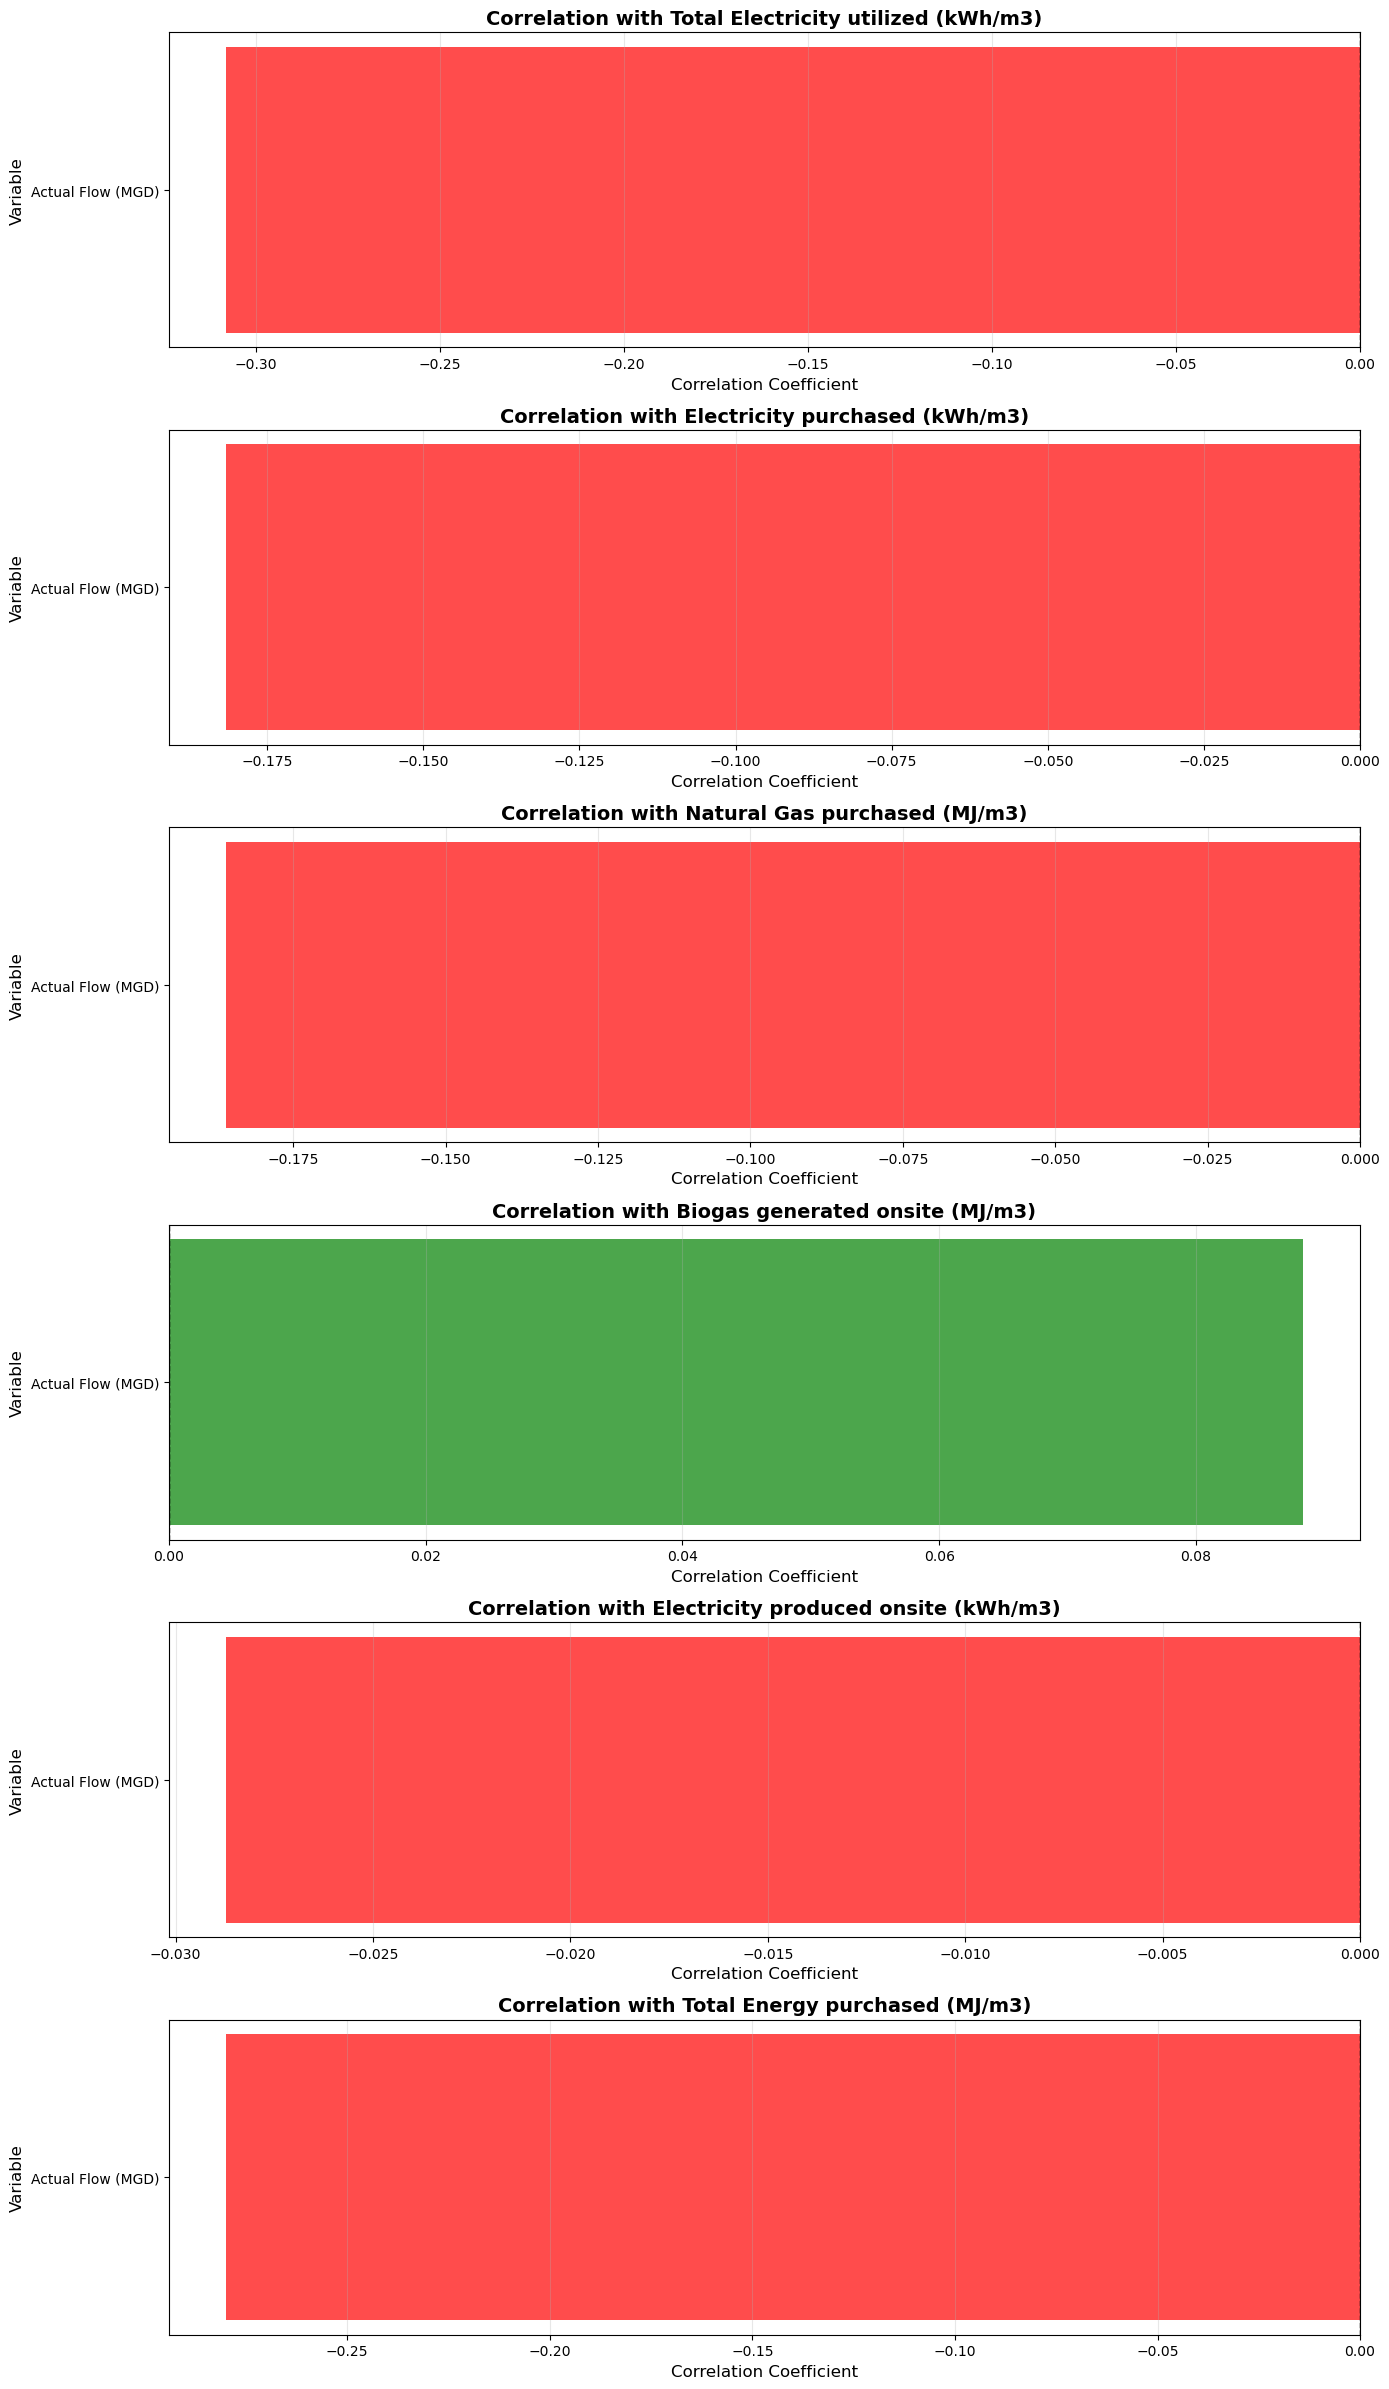

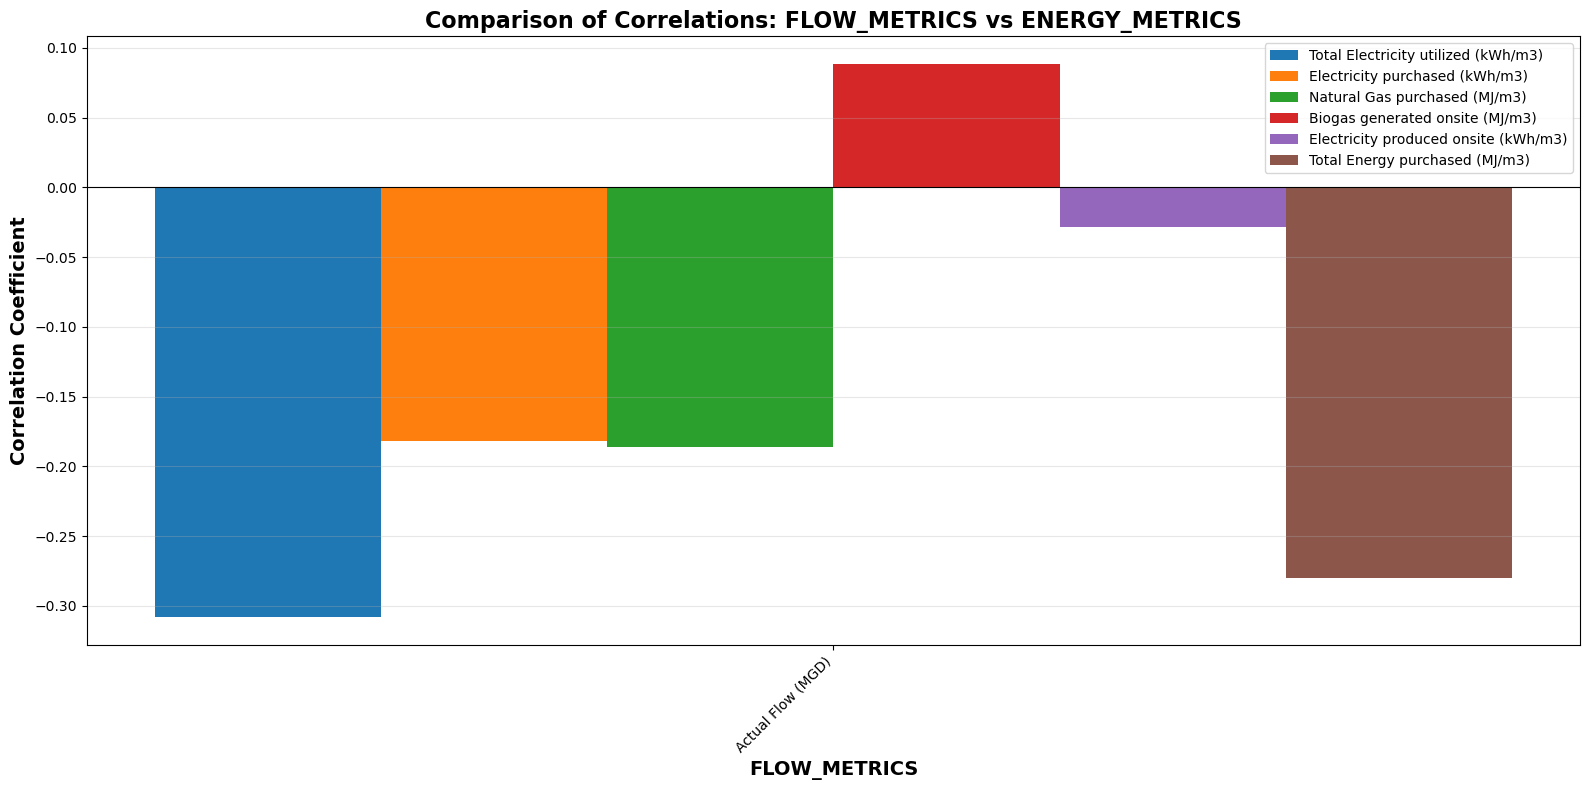

In [105]:
    # Modular Correlation Analysis Framework
    # Allows flexible correlation analysis between different variable groups
    # With configurable significance levels

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy.stats import spearmanr, pearsonr
    import os
    from typing import List, Dict, Tuple, Optional, Union
    from enum import Enum


    # =============================================================================
    # CONFIGURATION: Define Variable Groups
    # =============================================================================

    class VariableType(Enum):
        """Enumeration of variable types for correlation analysis."""
        PROCESS_CODES = "process_codes"
        ENERGY_METRICS = "energy_metrics"
        POLLUTANT_CONCENTRATIONS = "pollutant_concentrations"
        POLLUTANT_REDUCTIONS = "pollutant_reductions"
        FLOW_METRICS = "flow_metrics"
        CUSTOM = "custom"


    # Define your variable groups here - customize as needed
    VARIABLE_GROUPS = {
        VariableType.ENERGY_METRICS: {
            'columns': [
                'Electricity_consumed_onsite_kWh_per_m3',
                'Electricity_purchased_from_utility_kWh_per_m3',
                'NATURAL_GAS_PURCHASED_onsite_MJ_per_m3',
                'Biogas_generated_onsite_MJ_per_m3',
                'Electricity_produced_onsite_kWh_per_m3',
                'Total energy purchased_MJ_per_m3_survey'
            ],
            'display_names': {
                'Electricity_consumed_onsite_kWh_per_m3' : 'Total Electricity utilized (kWh/m3)',
                'Electricity_purchased_from_utility_kWh_per_m3': 'Electricity purchased (kWh/m3)',
                'NATURAL_GAS_PURCHASED_onsite_MJ_per_m3': 'Natural Gas purchased (MJ/m3)',
                'Biogas_generated_onsite_MJ_per_m3': 'Biogas generated onsite (MJ/m3)',
                'Electricity_produced_onsite_kWh_per_m3': 'Electricity produced onsite (kWh/m3)',
                'Total energy purchased_MJ_per_m3_survey': 'Total Energy purchased (MJ/m3)'
            },
            'is_categorical': False,
            'requires_encoding': False
        },
        VariableType.POLLUTANT_CONCENTRATIONS: {
            'columns': [
                'BOD_influent_mg_L',
                'BOD_effluent_mg_L',
                'TSS_influent_mg_L',
                'TSS_effluent_mg_L',
                'TN_influent_mg_L',
                'TN_effluent_mg_L',
                'TP_influent_mg_L',
                'TP_effluent_mg_L',
                'NH3_influent_mg_L',
                'NH3_effluent_mg_L'
            ],
            'display_names': {
                'BOD_influent_mg_L': 'BOD Influent (mg/L)',
                'BOD_effluent_mg_L': 'BOD Effluent (mg/L)',
                'TSS_influent_mg_L': 'TSS Influent (mg/L)',
                'TSS_effluent_mg_L': 'TSS Effluent (mg/L)',
                'TN_influent_mg_L': 'TN Influent (mg/L)',
                'TN_effluent_mg_L': 'TN Effluent (mg/L)',
                'TP_influent_mg_L': 'TP Influent (mg/L)',
                'TP_effluent_mg_L': 'TP Effluent (mg/L)',
                'NH3_influent_mg_L': 'NH3 Influent (mg/L)',
                'NH3_effluent_mg_L': 'NH3 Effluent (mg/L)'
            },
            'is_categorical': False,
            'requires_encoding': False
        },
        VariableType.FLOW_METRICS: {
            'columns': [
                'ACTUAL_FLOW_AVG'
            ],
            'display_names': {
                'ACTUAL_FLOW_AVG': 'Actual Flow (MGD)'
            },
            'is_categorical': False,
            'requires_encoding': False
        },
        VariableType.PROCESS_CODES: {
            'columns': ['PREDICTED_WRRF_TT_CODE'],
            'display_names': {},  # Auto-generated after encoding
            'is_categorical': True,
            'requires_encoding': True,
            'encoding_type': 'binary_per_character',
            'encoding_prefix': 'Process',
            'filter_blanks': True,
            'char_replacements': {'*': 'P'}  # Characters to replace before encoding
        },
        VariableType.POLLUTANT_REDUCTIONS: {
            'columns': [
                'BOD5_AVG_reduction',
                'CBOD5_AVG_reduction',
                'SS_AVG_reduction',
                'VSS_AVG_reduction',
                'TS_AVG_reduction',
                'TSS_AVG_reduction',
                'VTS_AVG_reduction',
                'TKN_AVG_reduction',
                'TN_AVG_reduction',
                'NH3_N_AVG_reduction',
                'NO3_N_AVG_reduction',
                'NO2_N_AVG_reduction',
                'NO3_N+NO2_N_AVG_reduction',
                'P_TOTAL_AVG_reduction',
                'P_SOLID_AVG_reduction',
            ],
            'display_names': {
                'BOD5_AVG_reduction' : 'BOD5 (mg/L)',
                'CBOD5_AVG_reduction' : 'CBOD5 (mg/L)',
                'SS_AVG_reduction' : 'SS (mg/L)',
                'VSS_AVG_reduction' : 'VSS (mg/L)',
                'TS_AVG_reduction' : 'TS (mg/L)',
                'TSS_AVG_reduction' : 'TSS (mg/L)',
                'VTS_AVG_reduction' : 'VTS (mg/L)',
                'TKN_AVG_reduction' : 'TKN (mg/L)',
                'TN_AVG_reduction' : 'TN (mg/L)',
                'NH3_N_AVG_reduction' : 'NH3-N (mg/L)',
                'NO3_N_AVG_reduction' : 'NO3-N (mg/L)',
                'NO2_N_AVG_reduction' : 'NO2-N (mg/L)',
                'NO3_N+NO2_N_AVG_reduction' : 'NO3-N + NO2-N (mg/L)',
                'P_TOTAL_AVG_reduction' : 'P Total (mg/L)',
                'P_SOLID_AVG_reduction' : 'P Solid (mg/L)',
            },
            'is_categorical': False,
            'requires_encoding': False
        }
    }


    # =============================================================================
    # CORE CLASS
    # =============================================================================

    class CorrelationAnalyzer:
        """
        A modular class for performing correlation analysis between different
        variable groups in a DataFrame.
        """

        # ==========================================================================
        # SIGNIFICANCE LEVEL CONFIGURATION
        # ==========================================================================
        # Modify these values to change confidence thresholds
        # Format: (marker, p_value_threshold, confidence_level_description)
        # Listed from most stringent to least stringent
        DEFAULT_SIGNIFICANCE_LEVELS = [
            ('***', 0.01, '99%'),   # 99% confidence
            ('**', 0.05, '95%'),    # 95% confidence
            ('*', 0.10, '90%')      # 90% confidence (minimum)
        ]

        # Minimum p-value threshold for considering a result significant
        DEFAULT_MIN_SIGNIFICANCE = 0.10  # 90% confidence

        # ==========================================================================
        # SAMPLE SIZE CONFIGURATION
        # ==========================================================================
        # Pairs with n < DEFAULT_MIN_N are skipped entirely (NaN in output).
        # No soft warning is applied — results are either computed or skipped.
        DEFAULT_MIN_N = 10    # Hard minimum: skip computation below this

        def __init__(self,
                    df: pd.DataFrame,
                    output_path: str = '.',
                    significance_levels: List[Tuple[str, float, str]] = None,
                    min_significance: float = None,
                    min_n: int = None):
            """
            Initialize the CorrelationAnalyzer.

            Parameters:
            -----------
            df : pd.DataFrame
                The input DataFrame containing all variables
            output_path : str
                Path for saving output files
            significance_levels : List[Tuple[str, float, str]], optional
                Custom significance levels as list of (marker, p_threshold, description)
                Example: [('***', 0.01, '99%'), ('**', 0.05, '95%'), ('*', 0.10, '90%')]
            min_significance : float, optional
                Minimum p-value threshold for significance (default: 0.10)
            min_n : int, optional
                Hard minimum n; pairs with fewer valid observations are skipped (default: 10)
            """
            self.df_original = df.copy()
            self.df = df.copy()
            self.output_path = output_path
            self.encoded_columns = {}
            self.analysis_results = {}
            self.variable_groups = VARIABLE_GROUPS.copy()
            self._encoding_applied = {}
            self._preprocessing_applied = {}

            # Set significance levels
            self.significance_levels = significance_levels or self.DEFAULT_SIGNIFICANCE_LEVELS
            self.min_significance = min_significance or self.DEFAULT_MIN_SIGNIFICANCE

            # Sort significance levels by p-value (most stringent first)
            self.significance_levels = sorted(self.significance_levels, key=lambda x: x[1])

            # Set hard minimum sample size
            self.min_n = min_n if min_n is not None else self.DEFAULT_MIN_N

        def set_significance_levels(self,
                                    levels: List[Tuple[str, float, str]] = None,
                                    min_significance: float = None):
            """
            Update significance levels after initialization.

            Parameters:
            -----------
            levels : List[Tuple[str, float, str]], optional
                Custom significance levels as list of (marker, p_threshold, description)
            min_significance : float, optional
                Minimum p-value threshold for significance

            Example:
            --------
            # For 90%, 95%, 99% confidence levels:
            analyzer.set_significance_levels(
                levels=[('***', 0.01, '99%'), ('**', 0.05, '95%'), ('*', 0.10, '90%')],
                min_significance=0.10
            )

            # For traditional 95%, 99%, 99.9% confidence levels:
            analyzer.set_significance_levels(
                levels=[('***', 0.001, '99.9%'), ('**', 0.01, '99%'), ('*', 0.05, '95%')],
                min_significance=0.05
            )
            """
            if levels is not None:
                self.significance_levels = sorted(levels, key=lambda x: x[1])
            if min_significance is not None:
                self.min_significance = min_significance

            print(f"Significance levels updated:")
            for marker, p_val, desc in self.significance_levels:
                print(f"  {marker}: p < {p_val} ({desc} confidence)")
            print(f"Minimum significance threshold: p < {self.min_significance}")

        def set_min_n(self, min_n: int):
            """
            Update the hard minimum sample size threshold after initialization.

            Pairs with fewer than min_n valid observations are skipped entirely
            and appear as NaN in all outputs.

            Parameters:
            -----------
            min_n : int
                Hard minimum number of valid observations required to compute correlation

            Example:
            --------
            analyzer.set_min_n(20)
            """
            self.min_n = min_n
            print(f"Hard minimum sample size updated: n < {self.min_n} will be skipped")

        def _get_significance_marker(self, p_val: float) -> str:
            """
            Get the significance marker for a given p-value.

            Parameters:
            -----------
            p_val : float
                The p-value to evaluate

            Returns:
            --------
            str
                Significance marker (e.g., '***', '**', '*', or '')
            """
            if pd.isna(p_val):
                return ""

            for marker, threshold, _ in self.significance_levels:
                if p_val < threshold:
                    return marker
            return ""

        def _is_significant(self, p_val: float) -> bool:
            """
            Check if a p-value is significant based on minimum threshold.

            Parameters:
            -----------
            p_val : float
                The p-value to evaluate

            Returns:
            --------
            bool
                True if significant, False otherwise
            """
            if pd.isna(p_val):
                return False
            return p_val < self.min_significance

        def _get_significance_legend(self) -> str:
            """
            Generate legend text for significance markers.

            Returns:
            --------
            str
                Legend string for plot titles
            """
            parts = []
            for marker, threshold, _ in self.significance_levels:
                parts.append(f"{marker} p<{threshold}")
            return "(" + ", ".join(parts) + ")"

        def _get_significance_columns(self) -> Dict[str, float]:
            """
            Get dictionary of significance column names and thresholds.

            Returns:
            --------
            Dict[str, float]
                Dictionary mapping column names to p-value thresholds
            """
            return {f'Significant_{threshold}': threshold
                    for _, threshold, _ in self.significance_levels}

        def add_variable_group(self,
                            group_type: VariableType,
                            columns: List[str],
                            display_names: Dict[str, str] = None,
                            is_categorical: bool = False,
                            requires_encoding: bool = False,
                            encoding_type: str = None,
                            encoding_prefix: str = 'Encoded',
                            filter_blanks: bool = False,
                            char_replacements: Dict[str, str] = None):
            """
            Add or update a variable group configuration.

            Parameters:
            -----------
            group_type : VariableType
                The type of variable group
            columns : List[str]
                List of column names in this group
            display_names : Dict[str, str], optional
                Mapping of column names to display names
            is_categorical : bool
                Whether the variables are categorical
            requires_encoding : bool
                Whether encoding is required before analysis
            encoding_type : str, optional
                Type of encoding ('binary_per_character', etc.)
            encoding_prefix : str
                Prefix for encoded column names
            filter_blanks : bool
                Whether to filter out blank values
            char_replacements : Dict[str, str], optional
                Characters to replace before encoding
            """
            self.variable_groups[group_type] = {
                'columns': columns,
                'display_names': display_names or {},
                'is_categorical': is_categorical,
                'requires_encoding': requires_encoding,
                'encoding_type': encoding_type,
                'encoding_prefix': encoding_prefix,
                'filter_blanks': filter_blanks,
                'char_replacements': char_replacements or {}
            }

        def add_custom_variable_group(self,
                                    group_name: str,
                                    columns: List[str],
                                    display_names: Dict[str, str] = None,
                                    is_categorical: bool = False,
                                    requires_encoding: bool = False,
                                    encoding_type: str = None,
                                    encoding_prefix: str = 'Encoded',
                                    filter_blanks: bool = False,
                                    char_replacements: Dict[str, str] = None):
            """
            Add a custom variable group with a string name.

            Parameters:
            -----------
            group_name : str
                Name for the custom group
            columns : List[str]
                List of column names in this group
            display_names : Dict[str, str], optional
                Mapping of column names to display names
            is_categorical : bool
                Whether the variables are categorical
            requires_encoding : bool
                Whether encoding is required before analysis
            encoding_type : str, optional
                Type of encoding ('binary_per_character', etc.)
            encoding_prefix : str
                Prefix for encoded column names
            filter_blanks : bool
                Whether to filter out blank values
            char_replacements : Dict[str, str], optional
                Characters to replace before encoding
            """
            self.variable_groups[group_name] = {
                'columns': columns,
                'display_names': display_names or {},
                'is_categorical': is_categorical,
                'requires_encoding': requires_encoding,
                'encoding_type': encoding_type,
                'encoding_prefix': encoding_prefix,
                'filter_blanks': filter_blanks,
                'char_replacements': char_replacements or {}
            }

        def _filter_blank_values(self, column: str, verbose: bool = True) -> int:
            """
            Filter out rows where a specified column has blank values.

            Parameters:
            -----------
            column : str
                Column name to check for blank values
            verbose : bool
                Whether to print filtering information

            Returns:
            --------
            int
                Number of rows dropped
            """
            blank_mask = (
                self.df[column].isna() |
                self.df[column].astype(str).str.strip().eq('') |
                self.df[column].astype(str).str.strip().eq('nan')
            )

            dropped_rows = self.df[blank_mask]
            num_dropped = len(dropped_rows)

            if verbose:
                print("=" * 80)
                print(f"FILTERING: Dropping rows with blank {column}")
                print("=" * 80)
                print(f"Number of rows dropped: {num_dropped}")

                if num_dropped > 0 and 'CWNS_ID' in self.df.columns:
                    print(f"\nCWNS_IDs of dropped rows:")
                    for cwns_id in dropped_rows['CWNS_ID'].values[:10]:
                        print(f"  - {cwns_id}")
                    if num_dropped > 10:
                        print(f"  ... and {num_dropped - 10} more")
                print("=" * 80)

            self.df = self.df[~blank_mask].copy()

            if verbose:
                print(f"Remaining rows after filtering: {len(self.df)}\n")

            return num_dropped

        def _replace_characters(self, column: str, replacements: Dict[str, str],
                                verbose: bool = True):
            """
            Replace characters in a column.

            Parameters:
            -----------
            column : str
                Column name
            replacements : Dict[str, str]
                Dictionary of old_char: new_char replacements
            verbose : bool
                Whether to print information
            """
            if column not in self.df.columns:
                return

            for old_char, new_char in replacements.items():
                count = self.df[column].str.contains(old_char, na=False, regex=False).sum()
                if verbose and count > 0:
                    print(f"Replacing '{old_char}' with '{new_char}' in {column} ({count} rows affected)")
                self.df[column] = self.df[column].str.replace(old_char, new_char, regex=False)

            if verbose and replacements:
                print(f"Character replacement complete.\n")

        def _extract_unique_characters(self, column: str) -> List[str]:
            """
            Extract all unique characters from a column containing comma-separated values.

            Parameters:
            -----------
            column : str
                Column name

            Returns:
            --------
            List[str]
                Sorted list of unique characters
            """
            all_chars = set()
            for value in self.df[column].dropna():
                chars = str(value).replace(' ', '').split(',')
                for char in chars:
                    all_chars.update(list(char))
            return sorted(all_chars)

        def _create_binary_columns(self, column: str, unique_chars: List[str],
                                prefix: str = 'Process') -> List[str]:
            """
            Create binary columns for each unique character.

            Parameters:
            -----------
            column : str
                Source column name
            unique_chars : List[str]
                List of unique characters to encode
            prefix : str
                Prefix for new column names

            Returns:
            --------
            List[str]
                List of created column names
            """
            created_columns = []
            for char in unique_chars:
                col_name = f'{prefix}_{char}'
                self.df[col_name] = self.df[column].apply(
                    lambda x: 1 if pd.notna(x) and char in str(x).replace(',', '').replace(' ', '') else 0
                )
                created_columns.append(col_name)
            return created_columns

        def _prepare_variable_group(self, group_type: Union[VariableType, str],
                                    verbose: bool = True):
            """
            Prepare a variable group for analysis, applying encoding if necessary.
            This is called automatically when needed.

            Parameters:
            -----------
            group_type : VariableType or str
                The variable group to prepare
            verbose : bool
                Whether to print information
            """
            # Check if already prepared
            if group_type in self._preprocessing_applied:
                return

            config = self.variable_groups.get(group_type)
            if config is None:
                raise ValueError(f"Variable group {group_type} not found")

            # Only apply preprocessing for groups that require encoding
            if not config.get('requires_encoding', False):
                self._preprocessing_applied[group_type] = True
                return

            if verbose:
                print("\n" + "=" * 80)
                print(f"PREPARING VARIABLE GROUP: {group_type}")
                print("=" * 80)

            column = config['columns'][0]  # Assume single column for categorical

            # Step 1: Filter blank values if required
            if config.get('filter_blanks', False):
                self._filter_blank_values(column, verbose=verbose)

            # Step 2: Replace characters if specified
            char_replacements = config.get('char_replacements', {})
            if char_replacements:
                self._replace_characters(column, char_replacements, verbose=verbose)

            # Step 3: Apply encoding
            encoding_type = config.get('encoding_type', 'binary_per_character')
            prefix = config.get('encoding_prefix', 'Encoded')

            if encoding_type == 'binary_per_character':
                unique_chars = self._extract_unique_characters(column)
                if verbose:
                    print(f"Unique characters found in {column}: {unique_chars}")

                encoded_cols = self._create_binary_columns(column, unique_chars, prefix)
                self.encoded_columns[group_type] = encoded_cols

                # Update display names
                for col in encoded_cols:
                    config['display_names'][col] = col

                if verbose:
                    print(f"Created {len(encoded_cols)} binary columns for {column}")
                    print("\nEncoded columns:")
                    for col in encoded_cols:
                        count = self.df[col].sum()
                        pct = (count / len(self.df)) * 100
                        print(f"  {col}: {count} occurrences ({pct:.1f}%)")
            else:
                raise ValueError(f"Encoding type {encoding_type} not implemented")

            self._preprocessing_applied[group_type] = True
            self._encoding_applied[group_type] = True

            if verbose:
                print("=" * 80 + "\n")

        def rename_columns(self, rename_dict: Dict[str, str]):
            """
            Rename columns in the DataFrame.

            Parameters:
            -----------
            rename_dict : Dict[str, str]
                Mapping of old names to new names
            """
            self.df.rename(columns=rename_dict, inplace=True)

            # Update variable groups with new names
            for group_type, config in self.variable_groups.items():
                updated_columns = []
                for col in config['columns']:
                    if col in rename_dict:
                        updated_columns.append(rename_dict[col])
                    else:
                        updated_columns.append(col)
                config['columns'] = updated_columns

                # Update display names
                updated_display = {}
                for old_name, display_name in config['display_names'].items():
                    new_name = rename_dict.get(old_name, old_name)
                    updated_display[new_name] = display_name
                config['display_names'] = updated_display

        def get_analysis_columns(self, group_type: Union[VariableType, str]) -> List[str]:
            """
            Get the columns to use for analysis for a given variable group.
            Automatically triggers encoding if necessary.

            Parameters:
            -----------
            group_type : VariableType or str
                The variable group

            Returns:
            --------
            List[str]
                List of column names for analysis
            """
            config = self.variable_groups.get(group_type)
            if config is None:
                raise ValueError(f"Variable group {group_type} not found")

            # Prepare the group if it requires encoding and hasn't been prepared
            if config.get('requires_encoding', False) and group_type not in self._preprocessing_applied:
                self._prepare_variable_group(group_type)

            if config.get('requires_encoding', False) and group_type in self.encoded_columns:
                return self.encoded_columns[group_type]
            else:
                # Filter to only columns that exist in the DataFrame
                return [col for col in config['columns'] if col in self.df.columns]

        def calculate_correlations(self,
                                group_x: Union[VariableType, str],
                                group_y: Union[VariableType, str],
                                method: str = 'spearman',
                                verbose: bool = True) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
            """
            Calculate correlations between two variable groups.
            Automatically handles encoding for categorical variables.

            Pairs with n < min_n are skipped entirely and appear as NaN in all outputs.

            Parameters:
            -----------
            group_x : VariableType or str
                First variable group (rows in output)
            group_y : VariableType or str
                Second variable group (columns in output)
            method : str
                Correlation method ('spearman' or 'pearson')
            verbose : bool
                Whether to print detailed results

            Returns:
            --------
            Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]
                - Correlation matrix
                - P-value matrix
                - Detailed results DataFrame
            """
            # Get columns (this automatically triggers encoding if needed)
            cols_x = self.get_analysis_columns(group_x)
            cols_y = self.get_analysis_columns(group_y)

            if not cols_x:
                raise ValueError(f"No valid columns found for {group_x}. "
                                f"Check that columns exist in DataFrame.")
            if not cols_y:
                raise ValueError(f"No valid columns found for {group_y}. "
                                f"Check that columns exist in DataFrame.")

            # Initialize matrices
            corr_matrix = pd.DataFrame(index=cols_x, columns=cols_y, dtype=float)
            pval_matrix = pd.DataFrame(index=cols_x, columns=cols_y, dtype=float)
            # Store n (number of valid data points) for each pair
            n_matrix = pd.DataFrame(index=cols_x, columns=cols_y, dtype=float)
            detailed_results = []

            # Variables with insufficient variance
            insufficient_variance_x = []

            # Track pairs skipped due to n < min_n for reporting
            skipped_low_n = []

            # Get significance thresholds for detailed results
            sig_thresholds = self._get_significance_columns()

            if verbose:
                print("\n" + "=" * 80)
                print(f"CORRELATION ANALYSIS: {group_x} vs {group_y}")
                print(f"Method: {method.upper()}")
                print(f"Variables in X: {len(cols_x)}")
                print(f"Variables in Y: {len(cols_y)}")
                print(f"Significance levels: {self._get_significance_legend()}")
                print(f"Minimum n required to compute correlation: {self.min_n}")
                print("=" * 80)

            for col_x in cols_x:
                has_valid_correlation = False

                for col_y in cols_y:
                    # Remove rows with NaN values
                    valid_data = self.df[[col_x, col_y]].dropna()
                    n = len(valid_data)

                    # --- Hard minimum: skip computation entirely if n < min_n ---
                    if n < self.min_n:
                        corr_matrix.loc[col_x, col_y] = np.nan
                        pval_matrix.loc[col_x, col_y] = np.nan
                        n_matrix.loc[col_x, col_y] = n

                        skipped_low_n.append((col_x, col_y, n))

                        result_dict = {
                            'Variable_X': col_x,
                            'Variable_Y': col_y,
                            'Correlation': np.nan,
                            'P_Value': np.nan,
                            'N': n,
                            'Skipped_Low_N': True,   # Explicitly marks why result is NaN
                            'Significant': False
                        }
                        for col_name in sig_thresholds.keys():
                            result_dict[col_name] = False
                        detailed_results.append(result_dict)
                        continue

                    # --- Compute correlation for n >= min_n ---
                    if method == 'spearman':
                        corr, p_val = spearmanr(valid_data[col_x], valid_data[col_y])
                    else:
                        corr, p_val = pearsonr(valid_data[col_x], valid_data[col_y])

                    if not np.isnan(corr):
                        has_valid_correlation = True

                    corr_matrix.loc[col_x, col_y] = corr
                    pval_matrix.loc[col_x, col_y] = p_val
                    n_matrix.loc[col_x, col_y] = n

                    # Build result dictionary
                    result_dict = {
                        'Variable_X': col_x,
                        'Variable_Y': col_y,
                        'Correlation': corr,
                        'P_Value': p_val,
                        'N': n,
                        'Skipped_Low_N': False,
                        'Significant': self._is_significant(p_val)
                    }

                    # Add significance columns for each threshold
                    for col_name, threshold in sig_thresholds.items():
                        result_dict[col_name] = p_val < threshold if not np.isnan(p_val) else False

                    detailed_results.append(result_dict)

                if not has_valid_correlation:
                    insufficient_variance_x.append(col_x)

            detailed_df = pd.DataFrame(detailed_results)

            # Report pairs skipped due to low n
            if verbose and skipped_low_n:
                print("\n" + "-" * 80)
                print(f"PAIRS SKIPPED (n < {self.min_n} — insufficient data for reliable correlation):")
                print("-" * 80)
                for vx, vy, n_val in skipped_low_n:
                    print(f"  {vx} vs {vy}: n = {n_val}")

            # Report insufficient variance
            if verbose and insufficient_variance_x:
                print("\n" + "-" * 80)
                print("VARIABLES WITH INSUFFICIENT VARIANCE (excluded from visualizations):")
                print("-" * 80)
                for var in insufficient_variance_x:
                    print(f"  - {var}")

            # Filter out variables with insufficient variance
            valid_cols_x = [col for col in cols_x if col not in insufficient_variance_x]
            corr_matrix_filtered = corr_matrix.loc[valid_cols_x]
            pval_matrix_filtered = pval_matrix.loc[valid_cols_x]
            n_matrix_filtered = n_matrix.loc[valid_cols_x]

            # Print detailed results — includes n for each pair
            if verbose:
                print("\n" + "-" * 80)
                print("DETAILED CORRELATION RESULTS WITH P-VALUES")
                print("-" * 80)

                for col_y in cols_y:
                    print(f"\n{col_y}:")
                    print("-" * 60)
                    for col_x in valid_cols_x:
                        row = detailed_df[(detailed_df['Variable_X'] == col_x) &
                                        (detailed_df['Variable_Y'] == col_y)].iloc[0]

                        n_val = int(row['N'])

                        if row['Skipped_Low_N']:
                            # Clearly indicate why no result is shown
                            print(f"  {col_x:30s}: SKIPPED (n={n_val} < {self.min_n})")
                        elif pd.isna(row['Correlation']):
                            print(f"  {col_x:30s}: r = NaN (n={n_val}, insufficient variance)")
                        else:
                            marker = self._get_significance_marker(row['P_Value'])
                            print(f"  {col_x:30s}: r = {row['Correlation']:7.4f}, "
                                f"p = {row['P_Value']:.4f}, n = {n_val} {marker}")

            # Store results — include n_matrix for use in plots and reports
            analysis_key = f"{group_x}_vs_{group_y}"
            self.analysis_results[analysis_key] = {
                'correlation_matrix': corr_matrix_filtered,
                'pvalue_matrix': pval_matrix_filtered,
                'n_matrix': n_matrix_filtered,
                'detailed_results': detailed_df,
                'insufficient_variance': insufficient_variance_x,
                'skipped_low_n': skipped_low_n,
                'group_x': group_x,
                'group_y': group_y,
                'method': method
            }

            return corr_matrix_filtered, pval_matrix_filtered, detailed_df

        def _create_annotated_labels(self, corr_df: pd.DataFrame,
                                    pval_df: pd.DataFrame,
                                    n_df: pd.DataFrame) -> pd.DataFrame:
            """
            Create annotation labels with correlation values, significance markers,
            and n (number of data points) for each cell.

            Skipped cells (n < min_n) show only 'n=N' so the reader knows why
            the cell is blank rather than seeing an unexplained empty cell.

            Parameters:
            -----------
            corr_df : pd.DataFrame
                Correlation matrix
            pval_df : pd.DataFrame
                P-value matrix
            n_df : pd.DataFrame
                Matrix of n values (number of valid data points per pair)

            Returns:
            --------
            pd.DataFrame
                Matrix of annotation strings showing r, significance marker, and n
            """
            annot_matrix = corr_df.copy().astype(str)
            for col in corr_df.columns:
                for idx in corr_df.index:
                    corr_val = corr_df.loc[idx, col]
                    p_val = pval_df.loc[idx, col]
                    n_val = n_df.loc[idx, col]
                    n_int = int(n_val) if not pd.isna(n_val) else 0

                    if pd.isna(corr_val) or pd.isna(p_val):
                        # Show n so the reader knows the cell was skipped due to low n
                        annot_matrix.loc[idx, col] = f'n={n_int}'
                    else:
                        marker = self._get_significance_marker(p_val)
                        # First line: correlation + significance marker
                        # Second line: n for convenient reading
                        annot_matrix.loc[idx, col] = f'{corr_val:.3f}{marker}\nn={n_int}'
            return annot_matrix

        def plot_heatmap(self,
                        analysis_key: str = None,
                        group_x: Union[VariableType, str] = None,
                        group_y: Union[VariableType, str] = None,
                        figsize: Tuple[int, int] = (16, 10),
                        show_significance: bool = True,
                        save: bool = True,
                        filename: str = None,
                        xlabel: str = None,
                        ylabel: str = None,
                        title_fontsize: int = 18,
                        xlabel_fontsize: int = 14,
                        ylabel_fontsize: int = 14,
                        xtick_fontsize: int = 12,
                        ytick_fontsize: int = 12,
                        annot_fontsize: int = 11,
                        cbar_label_fontsize: int = 12):
            """
            Plot correlation heatmap with correlation values, significance markers,
            and n annotated in each cell.

            Cells where n < min_n show only 'n=N' to explain the missing value.

            Parameters:
            -----------
            analysis_key : str, optional
                Key for previously calculated analysis
            group_x, group_y : VariableType or str, optional
                Variable groups (if analysis_key not provided)
            figsize : Tuple[int, int]
                Figure size
            show_significance : bool
                Whether to show significance markers
            save : bool
                Whether to save the figure
            filename : str, optional
                Custom filename for saving
            xlabel : str, optional
                Custom x-axis label; defaults to the group_x name if not provided
            ylabel : str, optional
                Custom y-axis label; defaults to the group_y name if not provided
            title_fontsize : int
                Font size for the title (default: 18)
            xlabel_fontsize : int
                Font size for x-axis label (default: 14)
            ylabel_fontsize : int
                Font size for y-axis label (default: 14)
            xtick_fontsize : int
                Font size for x-axis tick labels (default: 12)
            ytick_fontsize : int
                Font size for y-axis tick labels (default: 12)
            annot_fontsize : int
                Font size for cell annotations (default: 11)
            cbar_label_fontsize : int
                Font size for colorbar label (default: 12)
            """
            if analysis_key is None:
                if group_x is None or group_y is None:
                    raise ValueError("Must provide either analysis_key or both group_x and group_y")
                analysis_key = f"{group_x}_vs_{group_y}"

            if analysis_key not in self.analysis_results:
                if group_x is not None and group_y is not None:
                    self.calculate_correlations(group_x, group_y)
                else:
                    raise ValueError(f"Analysis {analysis_key} not found. Run calculate_correlations first.")

            results = self.analysis_results[analysis_key]
            corr_matrix = results['correlation_matrix']
            pval_matrix = results['pvalue_matrix']
            n_matrix = results['n_matrix']

            # Derive default axis labels from group names; use custom labels if provided
            group_x_name = str(results['group_x']).replace('VariableType.', '')
            group_y_name = str(results['group_y']).replace('VariableType.', '')
            x_label = xlabel if xlabel is not None else group_x_name
            y_label = ylabel if ylabel is not None else group_y_name

            plt.figure(figsize=figsize)

            if show_significance:
                # Annotate each cell with r, significance marker, and n
                annot_labels = self._create_annotated_labels(corr_matrix, pval_matrix, n_matrix)
                sns.heatmap(corr_matrix.T.astype(float), annot=annot_labels.T, cmap='coolwarm', center=0,
                            fmt='', square=False, linewidths=0.5,
                            cbar_kws={'label': 'Correlation Coefficient'},
                            annot_kws={'size': annot_fontsize})
                title_suffix = '\n' + self._get_significance_legend()
            else:
                sns.heatmap(corr_matrix.T.astype(float), annot=True, cmap='coolwarm', center=0,
                            fmt='.3f', square=False, linewidths=0.5,
                            cbar_kws={'label': 'Correlation Coefficient'},
                            annot_kws={'size': annot_fontsize})
                title_suffix = ''

            plt.title(f'Correlation Heatmap: {group_x_name} vs {group_y_name}{title_suffix}',
                    fontsize=title_fontsize, fontweight='bold')
            plt.xlabel(x_label, fontsize=xlabel_fontsize)
            plt.ylabel(y_label, fontsize=ylabel_fontsize)
            plt.xticks(rotation=45, ha='right', fontsize=xtick_fontsize)
            plt.yticks(rotation=0, fontsize=ytick_fontsize)
            
            # Update colorbar label font size
            cbar = plt.gca().collections[0].colorbar
            if cbar is not None:
                cbar.ax.tick_params(labelsize=cbar_label_fontsize)
                cbar.set_label('Correlation Coefficient', fontsize=cbar_label_fontsize)
            
            plt.tight_layout()

            if save:
                if filename is None:
                    filename = f'correlation_heatmap_{group_x_name}_vs_{group_y_name}.png'
                plt.savefig(os.path.join(self.output_path, filename), dpi=300, bbox_inches='tight')

            plt.show()

        def plot_bar_charts(self,
                            analysis_key: str = None,
                            group_x: Union[VariableType, str] = None,
                            group_y: Union[VariableType, str] = None,
                            figsize_per_chart: Tuple[int, int] = (14, 4),
                            save: bool = True,
                            filename: str = None,
                            title_fontsize: int = 14,
                            xlabel_fontsize: int = 12,
                            ylabel_fontsize: int = 12,
                            tick_fontsize: int = 10):
            """
            Plot individual bar charts for each variable in group_y.

            Parameters:
            -----------
            analysis_key : str, optional
                Key for previously calculated analysis
            group_x, group_y : VariableType or str, optional
                Variable groups (if analysis_key not provided)
            figsize_per_chart : Tuple[int, int]
                Figure size per chart
            save : bool
                Whether to save the figure
            filename : str, optional
                Custom filename for saving
            title_fontsize : int
                Font size for chart titles (default: 14)
            xlabel_fontsize : int
                Font size for x-axis labels (default: 12)
            ylabel_fontsize : int
                Font size for y-axis labels (default: 12)
            tick_fontsize : int
                Font size for tick labels (default: 10)
            """
            if analysis_key is None:
                if group_x is None or group_y is None:
                    raise ValueError("Must provide either analysis_key or both group_x and group_y")
                analysis_key = f"{group_x}_vs_{group_y}"

            if analysis_key not in self.analysis_results:
                raise ValueError(f"Analysis {analysis_key} not found. Run calculate_correlations first.")

            results = self.analysis_results[analysis_key]
            corr_matrix = results['correlation_matrix']

            cols_y = corr_matrix.columns.tolist()
            n_charts = len(cols_y)

            fig, axes = plt.subplots(n_charts, 1, figsize=(figsize_per_chart[0], figsize_per_chart[1] * n_charts))
            if n_charts == 1:
                axes = [axes]

            for idx, col_y in enumerate(cols_y):
                corr_data = corr_matrix[col_y].dropna().sort_values(ascending=True)

                colors = ['red' if x < 0 else 'green' for x in corr_data.values]
                axes[idx].barh(corr_data.index, corr_data.values, color=colors, alpha=0.7)
                axes[idx].axvline(x=0, color='black', linestyle='--', linewidth=1)
                axes[idx].set_xlabel('Correlation Coefficient', fontsize=xlabel_fontsize)
                axes[idx].set_ylabel('Variable', fontsize=ylabel_fontsize)
                axes[idx].set_title(f'Correlation with {col_y}', fontsize=title_fontsize, fontweight='bold')
                axes[idx].tick_params(axis='both', labelsize=tick_fontsize)
                axes[idx].grid(axis='x', alpha=0.3)

            plt.tight_layout()

            if save:
                group_x_name = str(results['group_x']).replace('VariableType.', '')
                group_y_name = str(results['group_y']).replace('VariableType.', '')
                if filename is None:
                    filename = f'correlation_bars_{group_x_name}_vs_{group_y_name}.png'
                plt.savefig(os.path.join(self.output_path, filename), dpi=300, bbox_inches='tight')

            plt.show()

        def plot_grouped_comparison(self,
                                    analysis_key: str = None,
                                    group_x: Union[VariableType, str] = None,
                                    group_y: Union[VariableType, str] = None,
                                    figsize: Tuple[int, int] = (16, 8),
                                    save: bool = True,
                                    filename: str = None,
                                    title_fontsize: int = 16,
                                    xlabel_fontsize: int = 14,
                                    ylabel_fontsize: int = 14,
                                    tick_fontsize: int = 10,
                                    legend_fontsize: int = 10):
            """
            Plot grouped bar chart comparing correlations across all variables in group_y.

            Parameters:
            -----------
            analysis_key : str, optional
                Key for previously calculated analysis
            group_x, group_y : VariableType or str, optional
                Variable groups (if analysis_key not provided)
            figsize : Tuple[int, int]
                Figure size
            save : bool
                Whether to save the figure
            filename : str, optional
                Custom filename for saving
            title_fontsize : int
                Font size for title (default: 16)
            xlabel_fontsize : int
                Font size for x-axis label (default: 14)
            ylabel_fontsize : int
                Font size for y-axis label (default: 14)
            tick_fontsize : int
                Font size for tick labels (default: 10)
            legend_fontsize : int
                Font size for legend (default: 10)
            """
            if analysis_key is None:
                if group_x is None or group_y is None:
                    raise ValueError("Must provide either analysis_key or both group_x and group_y")
                analysis_key = f"{group_x}_vs_{group_y}"

            if analysis_key not in self.analysis_results:
                raise ValueError(f"Analysis {analysis_key} not found. Run calculate_correlations first.")

            results = self.analysis_results[analysis_key]
            corr_matrix = results['correlation_matrix']

            cols_x = corr_matrix.index.tolist()
            cols_y = corr_matrix.columns.tolist()

            x = np.arange(len(cols_x))
            width = 0.8 / len(cols_y)

            fig, ax = plt.subplots(figsize=figsize)

            for i, col_y in enumerate(cols_y):
                offset = width * (i - len(cols_y) / 2 + 0.5)
                values = corr_matrix[col_y].values
                ax.bar(x + offset, values, width, label=col_y)

            group_x_name = str(results['group_x']).replace('VariableType.', '')
            group_y_name = str(results['group_y']).replace('VariableType.', '')

            ax.set_xlabel(group_x_name, fontsize=xlabel_fontsize, fontweight='bold')
            ax.set_ylabel('Correlation Coefficient', fontsize=ylabel_fontsize, fontweight='bold')
            ax.set_title(f'Comparison of Correlations: {group_x_name} vs {group_y_name}',
                        fontsize=title_fontsize, fontweight='bold')
            ax.set_xticks(x)
            ax.set_xticklabels(cols_x, rotation=45, ha='right', fontsize=tick_fontsize)
            ax.tick_params(axis='y', labelsize=tick_fontsize)
            ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
            ax.legend(loc='best', fontsize=legend_fontsize)
            ax.grid(axis='y', alpha=0.3)

            plt.tight_layout()

            if save:
                if filename is None:
                    filename = f'correlation_grouped_{group_x_name}_vs_{group_y_name}.png'
                plt.savefig(os.path.join(self.output_path, filename), dpi=300, bbox_inches='tight')

            plt.show()

        def plot_full_correlation_matrix(self,
                                        groups: List[Union[VariableType, str]],
                                        figsize: Tuple[int, int] = (18, 16),
                                        save: bool = True,
                                        filename: str = 'full_correlation_matrix.png',
                                        title_fontsize: int = 20,
                                        tick_fontsize: int = 10,
                                        annot_fontsize: int = 8,
                                        cbar_label_fontsize: int = 12):
            """
            Create a full correlation matrix including all variables from specified groups.

            Parameters:
            -----------
            groups : List[Union[VariableType, str]]
                List of variable groups to include
            figsize : Tuple[int, int]
                Figure size
            save : bool
                Whether to save the figure
            filename : str
                Filename for saving
            title_fontsize : int
                Font size for title (default: 20)
            tick_fontsize : int
                Font size for tick labels (default: 10)
            annot_fontsize : int
                Font size for cell annotations (default: 8)
            cbar_label_fontsize : int
                Font size for colorbar label (default: 12)

            Returns:
            --------
            pd.DataFrame
                Full correlation matrix
            """
            all_columns = []
            for group in groups:
                cols = self.get_analysis_columns(group)
                all_columns.extend(cols)

            # Remove duplicates while preserving order
            seen = set()
            unique_columns = []
            for col in all_columns:
                if col not in seen:
                    seen.add(col)
                    unique_columns.append(col)

            full_corr_matrix = self.df[unique_columns].corr(method='spearman')

            plt.figure(figsize=figsize)
            sns.heatmap(full_corr_matrix, annot=True, cmap='coolwarm', center=0,
                        fmt='.2f', square=True, linewidths=0.5,
                        cbar_kws={'label': 'Correlation Coefficient'},
                        annot_kws={'size': annot_fontsize})
            plt.title('Full Correlation Matrix', fontsize=title_fontsize, fontweight='bold')
            plt.xticks(fontsize=tick_fontsize, rotation=45, ha='right')
            plt.yticks(fontsize=tick_fontsize)
            
            # Update colorbar label font size
            cbar = plt.gca().collections[0].colorbar
            if cbar is not None:
                cbar.ax.tick_params(labelsize=cbar_label_fontsize)
                cbar.set_label('Correlation Coefficient', fontsize=cbar_label_fontsize)
            
            plt.tight_layout()

            if save:
                plt.savefig(os.path.join(self.output_path, filename), dpi=300, bbox_inches='tight')

            plt.show()

            return full_corr_matrix

        def export_results(self,
                        analysis_key: str = None,
                        group_x: Union[VariableType, str] = None,
                        group_y: Union[VariableType, str] = None,
                        prefix: str = None):
            """
            Export analysis results to CSV files.

            Parameters:
            -----------
            analysis_key : str, optional
                Key for previously calculated analysis
            group_x, group_y : VariableType or str, optional
                Variable groups (if analysis_key not provided)
            prefix : str, optional
                Prefix for output filenames
            """
            if analysis_key is None:
                if group_x is None or group_y is None:
                    raise ValueError("Must provide either analysis_key or both group_x and group_y")
                analysis_key = f"{group_x}_vs_{group_y}"

            if analysis_key not in self.analysis_results:
                raise ValueError(f"Analysis {analysis_key} not found. Run calculate_correlations first.")

            results = self.analysis_results[analysis_key]
            group_x_name = str(results['group_x']).replace('VariableType.', '')
            group_y_name = str(results['group_y']).replace('VariableType.', '')

            if prefix is None:
                prefix = f'{group_x_name}_vs_{group_y_name}'

            # Save correlation matrix
            results['correlation_matrix'].to_csv(
                os.path.join(self.output_path, f'{prefix}_correlation_matrix.csv')
            )

            # Save p-value matrix
            results['pvalue_matrix'].to_csv(
                os.path.join(self.output_path, f'{prefix}_pvalue_matrix.csv')
            )

            # Save n matrix (number of valid data points per pair)
            results['n_matrix'].to_csv(
                os.path.join(self.output_path, f'{prefix}_n_matrix.csv')
            )

            # Save detailed results (includes N and Skipped_Low_N columns)
            results['detailed_results'].to_csv(
                os.path.join(self.output_path, f'{prefix}_detailed_results.csv'),
                index=False
            )

            print(f"Results exported with prefix: {prefix}")

        def generate_summary_report(self,
                                    analysis_key: str = None,
                                    group_x: Union[VariableType, str] = None,
                                    group_y: Union[VariableType, str] = None,
                                    filename: str = None):
            """
            Generate a text summary report of the analysis.

            Each correlation entry includes n (number of data points).
            Pairs skipped due to n < min_n are clearly listed.

            Parameters:
            -----------
            analysis_key : str, optional
                Key for previously calculated analysis
            group_x, group_y : VariableType or str, optional
                Variable groups (if analysis_key not provided)
            filename : str, optional
                Custom filename for the report
            """
            if analysis_key is None:
                if group_x is None or group_y is None:
                    raise ValueError("Must provide either analysis_key or both group_x and group_y")
                analysis_key = f"{group_x}_vs_{group_y}"

            if analysis_key not in self.analysis_results:
                raise ValueError(f"Analysis {analysis_key} not found. Run calculate_correlations first.")

            results = self.analysis_results[analysis_key]
            group_x_name = str(results['group_x']).replace('VariableType.', '')
            group_y_name = str(results['group_y']).replace('VariableType.', '')

            if filename is None:
                filename = f'{group_x_name}_vs_{group_y_name}_summary.txt'

            with open(os.path.join(self.output_path, filename), 'w') as f:
                f.write("CORRELATION ANALYSIS SUMMARY REPORT\n")
                f.write("=" * 80 + "\n\n")

                f.write(f"Analysis: {group_x_name} vs {group_y_name}\n")
                f.write(f"Method: {results['method'].upper()}\n")
                f.write(f"Total records: {len(self.df)}\n")
                f.write(f"Significance levels: {self._get_significance_legend()}\n")
                f.write(f"Minimum significance threshold: p < {self.min_significance}\n")
                f.write(f"Minimum n required to compute correlation: {self.min_n}\n\n")

                f.write(f"Variables in {group_x_name}: {len(results['correlation_matrix'].index)}\n")
                f.write(f"Variables in {group_y_name}: {len(results['correlation_matrix'].columns)}\n\n")

                if results['insufficient_variance']:
                    f.write("Variables excluded (insufficient variance):\n")
                    for var in results['insufficient_variance']:
                        f.write(f"  - {var}\n")
                    f.write("\n")

                if results['skipped_low_n']:
                    f.write(f"Pairs skipped (n < {self.min_n} — insufficient data):\n")
                    for vx, vy, n_val in results['skipped_low_n']:
                        f.write(f"  - {vx} vs {vy}: n = {n_val}\n")
                    f.write("\n")

                f.write("=" * 80 + "\n")
                f.write("CORRELATION RESULTS\n")
                f.write("=" * 80 + "\n\n")

                detailed_df = results['detailed_results']

                for col_y in results['correlation_matrix'].columns:
                    f.write(f"\n{col_y}:\n")
                    f.write("-" * 60 + "\n")

                    subset = detailed_df[detailed_df['Variable_Y'] == col_y].sort_values(
                        'Correlation', ascending=False
                    )

                    for _, row in subset.iterrows():
                        n_val = int(row['N']) if not pd.isna(row['N']) else 0

                        if row['Skipped_Low_N']:
                            # Clearly indicate the pair was skipped due to low n
                            f.write(f"  {row['Variable_X']:30s}: SKIPPED "
                                    f"(n = {n_val} < {self.min_n})\n")
                        elif pd.isna(row['Correlation']):
                            f.write(f"  {row['Variable_X']:30s}: r = NaN, "
                                    f"n = {n_val}\n")
                        else:
                            marker = self._get_significance_marker(row['P_Value'])
                            # Include n alongside r and p for convenient reading
                            f.write(f"  {row['Variable_X']:30s}: r = {row['Correlation']:7.4f}, "
                                    f"p = {row['P_Value']:.4f}, n = {n_val} {marker}\n")

            print(f"Summary report saved: {filename}")

        def run_full_analysis(self,
                            group_x: Union[VariableType, str],
                            group_y: Union[VariableType, str],
                            method: str = 'spearman',
                            generate_plots: bool = True,
                            export_results: bool = True,
                            generate_report: bool = True,
                            xlabel: str = None,
                            ylabel: str = None,
                            title_fontsize: int = 18,
                            xlabel_fontsize: int = 14,
                            ylabel_fontsize: int = 14,
                            xtick_fontsize: int = 12,
                            ytick_fontsize: int = 12,
                            annot_fontsize: int = 11,
                            cbar_label_fontsize: int = 12):
            """
            Run a complete correlation analysis with all outputs.
            Encoding is automatically applied only when needed.

            Parameters:
            -----------
            group_x : VariableType or str
                First variable group
            group_y : VariableType or str
                Second variable group
            method : str
                Correlation method ('spearman' or 'pearson')
            generate_plots : bool
                Whether to generate visualizations
            export_results : bool
                Whether to export CSV files
            generate_report : bool
                Whether to generate summary report
            xlabel : str, optional
                Custom x-axis label for the heatmap; defaults to group_x name
            ylabel : str, optional
                Custom y-axis label for the heatmap; defaults to group_y name
            title_fontsize : int
                Font size for the title (default: 18)
            xlabel_fontsize : int
                Font size for x-axis label (default: 14)
            ylabel_fontsize : int
                Font size for y-axis label (default: 14)
            xtick_fontsize : int
                Font size for x-axis tick labels (default: 12)
            ytick_fontsize : int
                Font size for y-axis tick labels (default: 12)
            annot_fontsize : int
                Font size for cell annotations (default: 11)
            cbar_label_fontsize : int
                Font size for colorbar label (default: 12)

            Returns:
            --------
            Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]
                Correlation matrix, p-value matrix, detailed results
            """
            # Calculate correlations (encoding happens automatically if needed)
            corr_matrix, pval_matrix, detailed_df = self.calculate_correlations(
                group_x, group_y, method=method, verbose=True
            )

            analysis_key = f"{group_x}_vs_{group_y}"

            if generate_plots:
                # Pass custom axis labels and font sizes through to the heatmap
                self.plot_heatmap(
                    analysis_key=analysis_key,
                    xlabel=xlabel,
                    ylabel=ylabel,
                    title_fontsize=title_fontsize,
                    xlabel_fontsize=xlabel_fontsize,
                    ylabel_fontsize=ylabel_fontsize,
                    xtick_fontsize=xtick_fontsize,
                    ytick_fontsize=ytick_fontsize,
                    annot_fontsize=annot_fontsize,
                    cbar_label_fontsize=cbar_label_fontsize
                )
                self.plot_bar_charts(analysis_key=analysis_key)
                self.plot_grouped_comparison(analysis_key=analysis_key)

            if export_results:
                self.export_results(analysis_key=analysis_key)

            if generate_report:
                self.generate_summary_report(analysis_key=analysis_key)

            print("\n" + "=" * 80)
            print("ANALYSIS COMPLETE!")
            print("=" * 80)

            return corr_matrix, pval_matrix, detailed_df

        def _apply_display_name_renames(self):
            """
            Automatically rename DataFrame columns using display_names
            defined in VARIABLE_GROUPS, so the heatmap axes show
            human-readable labels without manual duplication.
            """
            rename_dict = {}
            for group_type, config in self.variable_groups.items():
                for original_col, display_name in config.get('display_names', {}).items():
                    # Only rename if the original column still exists in the DataFrame
                    if original_col in self.df.columns and original_col != display_name:
                        rename_dict[original_col] = display_name

            if rename_dict:
                self.rename_columns(rename_dict)
                print(f"Auto-renamed {len(rename_dict)} columns from display_names.")

            return rename_dict


    # =============================================================================
    # CONVENIENCE FUNCTIONS
    # =============================================================================

    def run_analysis(df, path_out, analysis_type='process_vs_energy',
                significance_levels=None, min_significance=None,
                min_n=None,
                xlabel=None, ylabel=None,
                title_fontsize=18,
                xlabel_fontsize=14,
                ylabel_fontsize=14,
                xtick_fontsize=12,
                ytick_fontsize=12,
                annot_fontsize=11,
                cbar_label_fontsize=12):
        """
        Run correlation analysis based on specified type.

        Parameters:
        -----------
        df : pd.DataFrame
            Input DataFrame
        path_out : str
            Output path for saving files
        analysis_type : str
            Type of analysis to run:
            - 'process_vs_energy': Process codes vs Energy metrics
            - 'pollutants_vs_energy': Pollutant concentrations vs Energy metrics
            - 'flow_vs_energy': Flow metrics vs Energy metrics
            - 'flow_vs_pollutants': Flow metrics vs Pollutant concentrations
            - 'all': Run all analyses
        significance_levels : List[Tuple[str, float, str]], optional
            Custom significance levels
        min_significance : float, optional
            Minimum p-value threshold for significance
        min_n : int, optional
            Hard minimum n; pairs with fewer valid observations are skipped (default: 10)
        xlabel : str, optional
            Custom x-axis label for the heatmap
        ylabel : str, optional
            Custom y-axis label for the heatmap
        title_fontsize : int
            Font size for titles (default: 18)
        xlabel_fontsize : int
            Font size for x-axis labels (default: 14)
        ylabel_fontsize : int
            Font size for y-axis labels (default: 14)
        xtick_fontsize : int
            Font size for x-axis tick labels (default: 12)
        ytick_fontsize : int
            Font size for y-axis tick labels (default: 12)
        annot_fontsize : int
            Font size for cell annotations (default: 11)
        cbar_label_fontsize : int
            Font size for colorbar label (default: 12)

        Returns:
        --------
        Tuple[CorrelationAnalyzer, Dict]
            Analyzer instance and results dictionary
        """

        # ── process_vs_energy: human-readable display names ──────────────────────
        # Maps encoded column names (e.g. 'Process_A') to the labels that will
        # appear on the heatmap axes.  Only used when analysis_type involves
        # PROCESS_CODES; has no effect on any other analysis branch.
        process_display_names = {
            'Process_A': 'Basic AS',
            'Process_B': 'Pure O2 AS',
            'Process_C': 'Trickling Filter',
            'Process_E': 'BNR, nitrification',
            'Process_F': 'BNR, denitrification',
            'Process_G': 'BNR, P removal',
            'Process_e': 'AD Electricity Gen',
            'Process_1': 'Aerobic Digestion',
            'Process_2': 'AD + thermal drying',
            'Process_3': 'Aerobic Digestion',
            'Process_4': 'Lime Stabilization',
            'Process_5': 'Incr., Multiple heart',
            'Process_6': 'Incr., Fluidized bed',
        }

        # Desired row order on the heatmap (display names, not raw column names).
        # Any display name not present in the data is silently ignored.
        process_sort_order = [
            'Basic AS',
            'Pure O2 AS',
            'Trickling Filter',
            'BNR, nitrification',
            'BNR, denitrification',
            'BNR, P removal',
            'Aerobic Digestion',
            'AD + thermal drying',
            'AD Electricity Gen',
            'Lime Stabilization',
            'Incr., Multiple heart',
            'Incr., Fluidized bed',
        ]
        # ─────────────────────────────────────────────────────────────────────────

        # Initialize the analyzer with custom significance levels and min_n
        analyzer = CorrelationAnalyzer(
            df,
            output_path=path_out,
            significance_levels=significance_levels,
            min_significance=min_significance,
            min_n=min_n
        )

        # Auto-rename ALL columns using display_names — no manual dict needed
        analyzer._apply_display_name_renames()

        # Define which analyses to run
        analyses_to_run = []

        if analysis_type == 'process_vs_energy' or analysis_type == 'all':
            analyses_to_run.append((VariableType.PROCESS_CODES, VariableType.ENERGY_METRICS))

        if analysis_type == 'pollutants_vs_energy' or analysis_type == 'all':
            analyses_to_run.append((VariableType.POLLUTANT_CONCENTRATIONS, VariableType.ENERGY_METRICS))

        if analysis_type == 'flow_vs_energy' or analysis_type == 'all':
            analyses_to_run.append((VariableType.FLOW_METRICS, VariableType.ENERGY_METRICS))

        if analysis_type == 'flow_vs_pollutants' or analysis_type == 'all':
            analyses_to_run.append((VariableType.FLOW_METRICS, VariableType.POLLUTANT_CONCENTRATIONS))

        if analysis_type == 'pollutants_reduction_vs_energy' or analysis_type == 'all':
            analyses_to_run.append((VariableType.POLLUTANT_REDUCTIONS, VariableType.ENERGY_METRICS))

        # Run the analyses
        results = {}
        for group_x, group_y in analyses_to_run:
            print(f"\n{'=' * 80}")
            print(f"Running analysis: {group_x} vs {group_y}")
            print(f"{'=' * 80}")

            corr, pval, detailed = analyzer.run_full_analysis(
                group_x=group_x,
                group_y=group_y,
                method='spearman',
                generate_plots=False,   # We'll handle plotting manually below
                export_results=True,
                generate_report=True,
                xlabel=xlabel,
                ylabel=ylabel,
                title_fontsize=title_fontsize,
                xlabel_fontsize=xlabel_fontsize,
                ylabel_fontsize=ylabel_fontsize,
                xtick_fontsize=xtick_fontsize,
                ytick_fontsize=ytick_fontsize,
                annot_fontsize=annot_fontsize,
                cbar_label_fontsize=cbar_label_fontsize
            )

            # ── process_vs_energy: rename rows & reorder ──────────────────────────
            # This block runs ONLY for the PROCESS_CODES × ENERGY_METRICS pair so
            # it cannot affect any other analysis branch.
            if group_x == VariableType.PROCESS_CODES:
                analysis_key = f"{group_x}_vs_{group_y}"
                stored = analyzer.analysis_results[analysis_key]

                for matrix_key in ('correlation_matrix', 'pvalue_matrix', 'n_matrix'):
                    mat = stored[matrix_key]

                    # 1. Rename index labels using process_display_names.
                    #    Only rows whose current index label appears in the dict
                    #    are renamed; all others are left unchanged.
                    mat.rename(index=process_display_names, inplace=True)

                    # 2. Reorder rows to match process_sort_order.
                    #    Keep only rows that actually exist in the matrix
                    #    (guards against missing processes in the dataset).
                    ordered_index = [
                        name for name in process_sort_order
                        if name in mat.index
                    ]
                    # Append any rows not covered by process_sort_order at the end
                    # so no data is silently dropped.
                    remaining = [idx for idx in mat.index if idx not in ordered_index]
                    mat = mat.loc[ordered_index + remaining]

                    stored[matrix_key] = mat

                # Persist the updated matrices back into the analyzer
                analyzer.analysis_results[analysis_key] = stored

                print(f"\nProcess rows renamed and reordered for '{analysis_key}'.")
            # ─────────────────────────────────────────────────────────────────────

            # Now generate the heatmap (and other plots) with the updated matrices
            analysis_key = f"{group_x}_vs_{group_y}"
            analyzer.plot_heatmap(
                analysis_key=analysis_key,
                xlabel=xlabel,
                ylabel=ylabel,
                title_fontsize=title_fontsize,
                xlabel_fontsize=xlabel_fontsize,
                ylabel_fontsize=ylabel_fontsize,
                xtick_fontsize=xtick_fontsize,
                ytick_fontsize=ytick_fontsize,
                annot_fontsize=annot_fontsize,
                cbar_label_fontsize=cbar_label_fontsize
            )
            analyzer.plot_bar_charts(analysis_key=analysis_key)
            analyzer.plot_grouped_comparison(analysis_key=analysis_key)

            results[analysis_key] = {
                'correlation': corr,
                'pvalue': pval,
                'detailed': detailed
            }

        # Save encoded data if process codes were analyzed
        if VariableType.PROCESS_CODES in analyzer._encoding_applied:
            analyzer.df.to_csv(os.path.join(path_out, 'encoded_data.csv'), index=False)
            print("\nEncoded data saved to: encoded_data.csv")

        return analyzer, results



    def quick_correlation(df: pd.DataFrame,
                        x_columns: List[str],
                        y_columns: List[str],
                        output_path: str = '.',
                        x_name: str = 'Group_X',
                        y_name: str = 'Group_Y',
                        method: str = 'spearman',
                        significance_levels: List[Tuple[str, float, str]] = None,
                        min_significance: float = None,
                        min_n: int = None,
                        title_fontsize: int = 18,
                        xlabel_fontsize: int = 14,
                        ylabel_fontsize: int = 14,
                        xtick_fontsize: int = 12,
                        ytick_fontsize: int = 12,
                        annot_fontsize: int = 11,
                        cbar_label_fontsize: int = 12):
        """
        Quick function for running correlation analysis between two sets of columns.
        No encoding is applied - use for continuous variables only.

        Parameters:
        -----------
        df : pd.DataFrame
            Input DataFrame
        x_columns : List[str]
            List of column names for X variables
        y_columns : List[str]
            List of column names for Y variables
        output_path : str
            Path for saving outputs
        x_name : str
            Display name for X variable group
        y_name : str
            Display name for Y variable group
        method : str
            Correlation method ('spearman' or 'pearson')
        significance_levels : List[Tuple[str, float, str]], optional
            Custom significance levels
        min_significance : float, optional
            Minimum p-value threshold for significance
        min_n : int, optional
            Hard minimum n; pairs with fewer valid observations are skipped (default: 10)
        title_fontsize : int
            Font size for titles (default: 18)
        xlabel_fontsize : int
            Font size for x-axis labels (default: 14)
        ylabel_fontsize : int
            Font size for y-axis labels (default: 14)
        xtick_fontsize : int
            Font size for x-axis tick labels (default: 12)
        ytick_fontsize : int
            Font size for y-axis tick labels (default: 12)
        annot_fontsize : int
            Font size for cell annotations (default: 11)
        cbar_label_fontsize : int
            Font size for colorbar label (default: 12)

        Returns:
        --------
        Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]
            Correlation matrix, p-value matrix, detailed results
        """
        analyzer = CorrelationAnalyzer(
            df,
            output_path=output_path,
            significance_levels=significance_levels,
            min_significance=min_significance,
            min_n=min_n
        )

        analyzer.add_custom_variable_group(
            group_name=x_name,
            columns=x_columns,
            requires_encoding=False
        )

        analyzer.add_custom_variable_group(
            group_name=y_name,
            columns=y_columns,
            requires_encoding=False
        )

        return analyzer.run_full_analysis(
            group_x=x_name,
            group_y=y_name,
            method=method,
            title_fontsize=title_fontsize,
            xlabel_fontsize=xlabel_fontsize,
            ylabel_fontsize=ylabel_fontsize,
            xtick_fontsize=xtick_fontsize,
            ytick_fontsize=ytick_fontsize,
            annot_fontsize=annot_fontsize,
            cbar_label_fontsize=cbar_label_fontsize
        )


    # =============================================================================
    # EXAMPLE USAGE
    # =============================================================================

    """
    # Example 1: Default axis labels and font sizes
    analyzer, results = run_analysis(df, path_out, analysis_type='pollutants_reduction_vs_energy')

    # Example 2: Custom axis labels and font sizes via run_full_analysis
    analyzer.run_full_analysis(
        group_x=VariableType.POLLUTANT_REDUCTIONS,
        group_y=VariableType.ENERGY_METRICS,
        xlabel='Pollutant Reductions',
        ylabel='Energy Metrics',
        title_fontsize=20,
        xlabel_fontsize=16,
        ylabel_fontsize=16,
        xtick_fontsize=14,
        ytick_fontsize=14,
        annot_fontsize=12,
        cbar_label_fontsize=14
    )

    # Example 3: Custom axis labels and font sizes on an already-computed heatmap
    analyzer.plot_heatmap(
        analysis_key='VariableType.POLLUTANT_REDUCTIONS_vs_VariableType.ENERGY_METRICS',
        xlabel='Pollutant Reductions',
        ylabel='Energy Metrics',
        title_fontsize=20,
        xlabel_fontsize=16,
        ylabel_fontsize=16,
        xtick_fontsize=14,
        ytick_fontsize=14,
        annot_fontsize=12,
        cbar_label_fontsize=14
    )

    # Example 4: Suppress axis labels entirely by passing empty strings
    analyzer.plot_heatmap(
        analysis_key='VariableType.POLLUTANT_REDUCTIONS_vs_VariableType.ENERGY_METRICS',
        xlabel='',
        ylabel='',
        title_fontsize=20,
        xtick_fontsize=14,
        ytick_fontsize=14,
        annot_fontsize=12
    )
    """


    # =============================================================================
    # RUN THE ANALYSIS
    # =============================================================================

    # Using 90% as minimum confidence level; skip pairs with n < 10
    analyzer, results = run_analysis(
        df,
        path_out,
        #analysis_type='process_vs_energy',
        analysis_type='flow_vs_energy',
        #analysis_type='pollutants_reduction_vs_energy',
        significance_levels=[
            ('***', 0.01, '99%'),
            ('**', 0.05, '95%'),
            ('*', 0.10, '90%')
        ],
        min_significance=0.10,
        min_n=10,    # Hard minimum: skip computation if fewer than 10 valid pairs
        #xlabel='Pollutant Reductions',  # Custom x-axis label for heatmap
        xlabel='',
        ylabel='Energy Metrics',         # Custom y-axis label for heatmap
        title_fontsize=20,              # Title font size
        xlabel_fontsize=18,   # X-axis label font size
        ylabel_fontsize=18,             # Y-axis label font size
        xtick_fontsize=18,              # X-axis tick label font size
        ytick_fontsize=18,              # Y-axis tick label font size
        annot_fontsize=18,              # Cell annotation font size
        cbar_label_fontsize=18          # Colorbar label font size
    )

NORMALITY TESTS FOR ENERGY VARIABLES

Total energy purchased_MJ_per_m3_survey:
  Skewness: 4.672 (Right-skewed)
  Kurtosis: 22.907
  Shapiro-Wilk p-value: 0.0000 (Non-normal)
  D'Agostino p-value: 0.0000 (Non-normal)

NATURAL_GAS_PURCHASED_onsite_MJ_per_m3:
  Skewness: 4.525 (Right-skewed)
  Kurtosis: 22.125
  Shapiro-Wilk p-value: 0.0000 (Non-normal)
  D'Agostino p-value: 0.0000 (Non-normal)

Biogas_generated_onsite_MJ_per_m3:
  Skewness: 0.731 (Right-skewed)
  Kurtosis: 0.603
  Shapiro-Wilk p-value: 0.0052 (Non-normal)
  D'Agostino p-value: 0.1325 (Normal)

Electricity_produced_onsite_kWh_per_m3:
  Skewness: 1.757 (Right-skewed)
  Kurtosis: 2.071
  Shapiro-Wilk p-value: 0.0000 (Non-normal)
  D'Agostino p-value: 0.0003 (Non-normal)


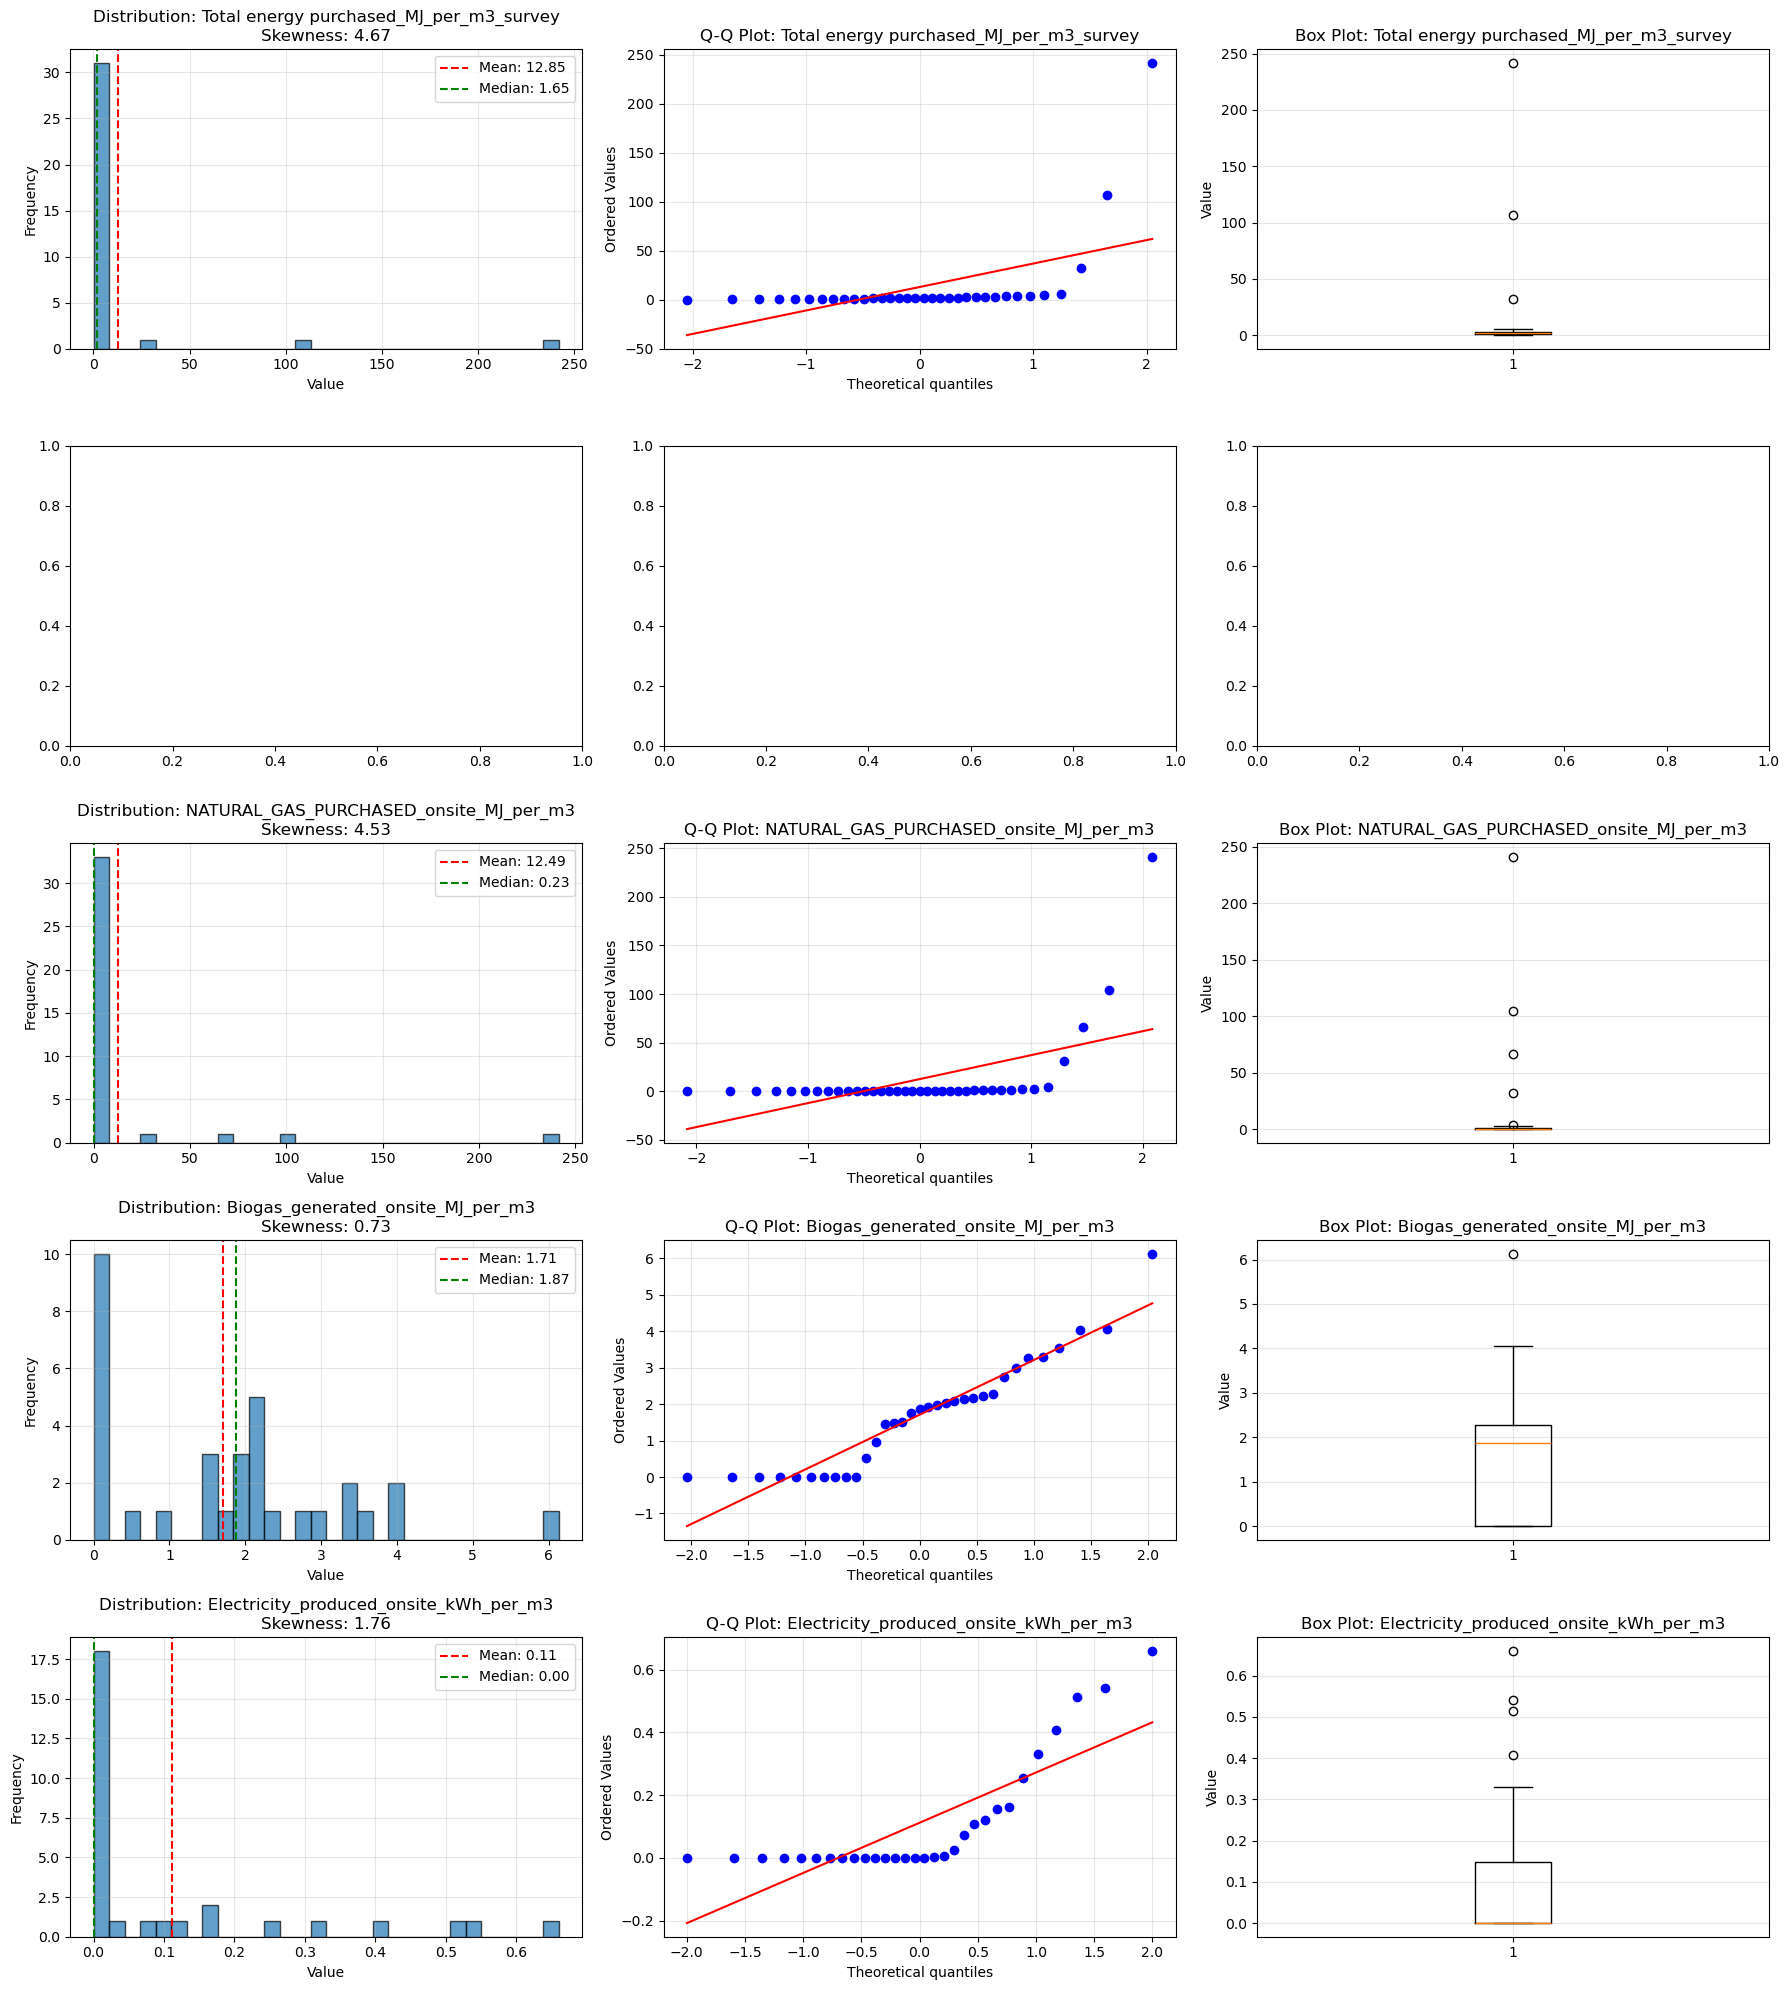


                                  Variable   N       Mean    Median        Std  Skewness   Kurtosis     Shapiro_p   DAgostino_p Normal
0  Total energy purchased_MJ_per_m3_survey  34  12.848411  1.648544  44.536627  4.671869  22.907074  1.249049e-11  3.072638e-15     No
1   NATURAL_GAS_PURCHASED_onsite_MJ_per_m3  37  12.494209  0.229696  43.720056  4.525038  22.124765  6.855747e-12  1.765425e-15     No
2        Biogas_generated_onsite_MJ_per_m3  33   1.710972  1.873572   1.523679  0.730773   0.602765  5.207465e-03  1.324600e-01     No
3   Electricity_produced_onsite_kWh_per_m3  30   0.111911  0.000000   0.189192  1.757021   2.070815  4.649202e-07  3.423779e-04     No

APPLYING TRANSFORMATIONS TO SKEWED VARIABLES

Total energy purchased_MJ_per_m3_survey (Skewness: 4.672):
  Log transform skewness: 2.640
  Sqrt transform skewness: 3.751
  Box-Cox transform skewness: -0.202 (λ=-0.120)
  → Best transformation: boxcox (skewness: -0.202)

NATURAL_GAS_PURCHASED_onsite_MJ_per_m3 (Skewness: 4.5

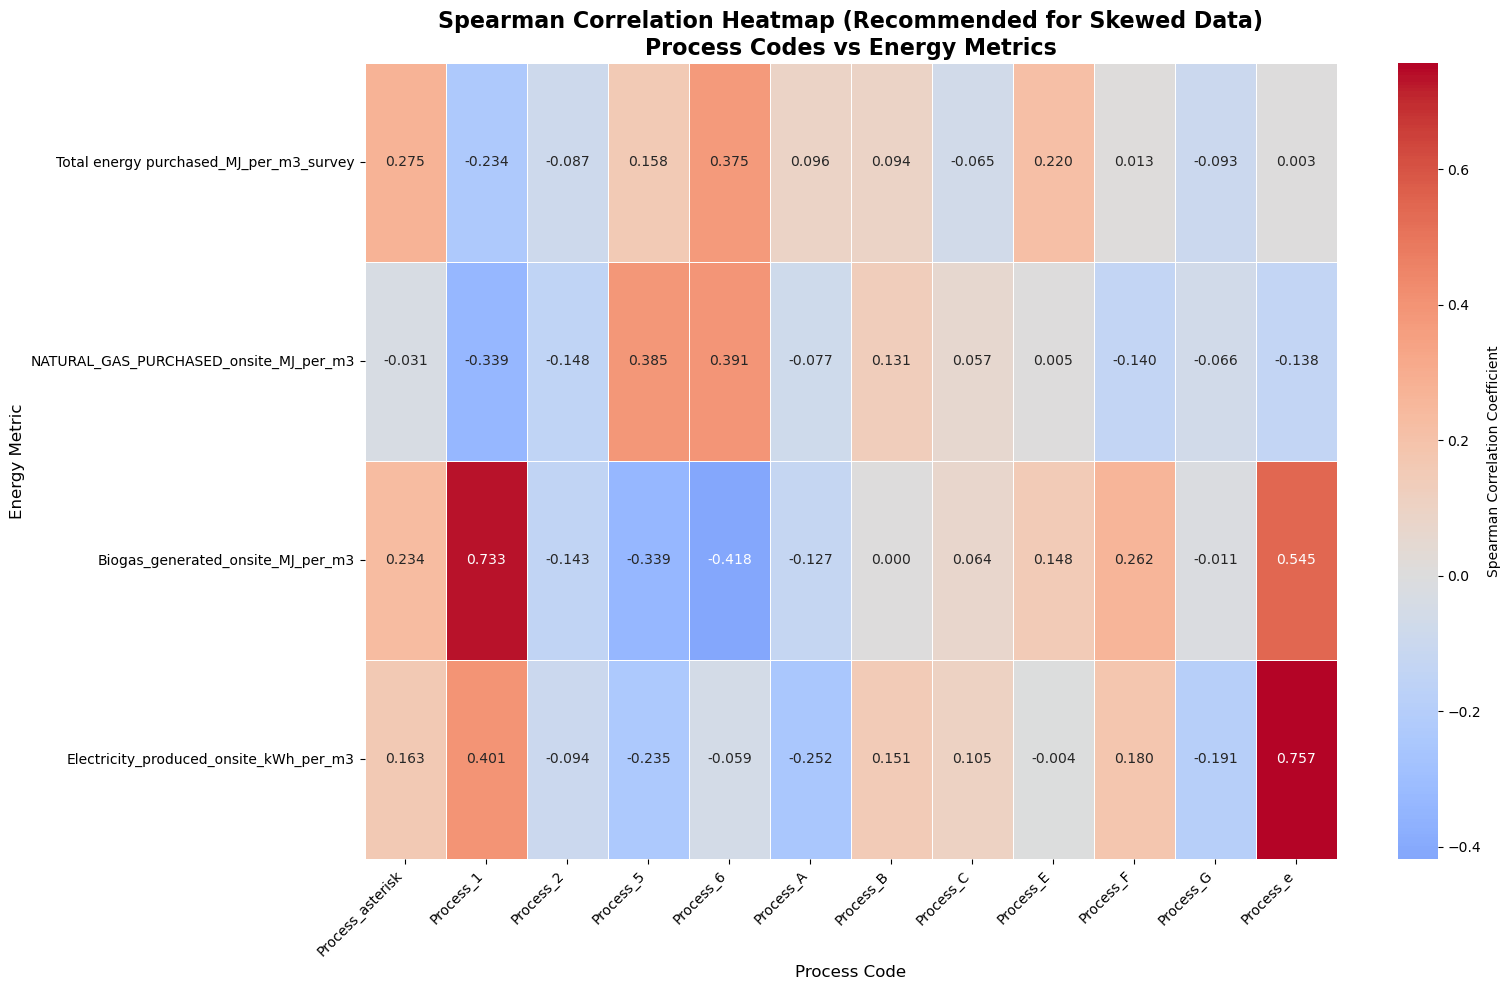


ANALYSIS SUMMARY AND RECOMMENDATIONS

Total energy purchased_MJ_per_m3_survey:
  Significant correlations (Pearson): 2/12
  Significant correlations (Spearman): 1/12
  Strongest Pearson: Process_6 (r=0.439)
  Strongest Spearman: Process_6 (r=0.375)
  Max discrepancy: 0.107
  → RECOMMENDATION: Use Spearman

NATURAL_GAS_PURCHASED_onsite_MJ_per_m3:
  Significant correlations (Pearson): 2/12
  Significant correlations (Spearman): 3/12
  Strongest Pearson: Process_6 (r=0.483)
  Strongest Spearman: Process_6 (r=0.391)
  Max discrepancy: 0.229
  → RECOMMENDATION: Use Spearman

Biogas_generated_onsite_MJ_per_m3:
  Significant correlations (Pearson): 3/12
  Significant correlations (Spearman): 3/12
  Strongest Pearson: Process_1 (r=0.735)
  Strongest Spearman: Process_1 (r=0.733)
  Max discrepancy: 0.048
  → RECOMMENDATION: Either method acceptable

Electricity_produced_onsite_kWh_per_m3:
  Significant correlations (Pearson): 2/12
  Significant correlations (Spearman): 2/12
  Strongest Pearson

In [97]:
# With multiple correlation methods and comprehensive analysis, we can now identify which process codes are most strongly associated with each energy metric, and whether those associations are statistically significant. This will help guide further analysis and potential interventions based on the identified relationships.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, kendalltau
from scipy.stats import shapiro, normaltest, boxcox
from scipy.special import inv_boxcox
import warnings
warnings.filterwarnings('ignore')

# Define all energy columns for analysis
energy_columns = [
    'Total energy purchased_MJ_per_m3_survey',
    'Electricity_purchased_from_utility_MJ_per_m3',
    'NATURAL_GAS_PURCHASED_onsite_MJ_per_m3',
    'Biogas_generated_onsite_MJ_per_m3',
    'Electricity_produced_onsite_kWh_per_m3'
]

# Step 1: Extract unique characters and create binary columns
def extract_unique_characters(column):
    all_chars = set()
    for value in column.dropna():
        chars = str(value).replace(' ', '').split(',')
        for char in chars:
            all_chars.update(list(char))
    return sorted(all_chars)

def create_binary_columns(df, column_name, unique_chars):
    df_encoded = df.copy()
    for char in unique_chars:
        if char == '*':
            col_name = 'Process_asterisk'
        else:
            col_name = f'Process_{char}'
        df_encoded[col_name] = df_encoded[column_name].apply(
            lambda x: 1 if pd.notna(x) and char in str(x).replace(',', '').replace(' ', '') else 0
        )
    return df_encoded

unique_chars = extract_unique_characters(df['PREDICTED_WRRF_TT_CODE'])
df_encoded = create_binary_columns(df, 'PREDICTED_WRRF_TT_CODE', unique_chars)

process_columns = []
for char in unique_chars:
    if char == '*':
        process_columns.append('Process_asterisk')
    else:
        process_columns.append(f'Process_{char}')

# Step 2: Test for normality and visualize distributions
print("="*80)
print("NORMALITY TESTS FOR ENERGY VARIABLES")
print("="*80)

normality_results = []

fig, axes = plt.subplots(len(energy_columns), 3, figsize=(18, 4*len(energy_columns)))
if len(energy_columns) == 1:
    axes = axes.reshape(1, -1)

for idx, energy_col in enumerate(energy_columns):
    if energy_col in df_encoded.columns:
        data = df_encoded[energy_col].dropna()
        
        # Normality tests
        shapiro_stat, shapiro_p = shapiro(data) if len(data) <= 5000 else (np.nan, np.nan)
        dagostino_stat, dagostino_p = normaltest(data) if len(data) >= 8 else (np.nan, np.nan)
        
        # Calculate skewness and kurtosis
        skewness = data.skew()
        kurtosis = data.kurtosis()
        
        normality_results.append({
            'Variable': energy_col,
            'N': len(data),
            'Mean': data.mean(),
            'Median': data.median(),
            'Std': data.std(),
            'Skewness': skewness,
            'Kurtosis': kurtosis,
            'Shapiro_p': shapiro_p,
            'DAgostino_p': dagostino_p,
            'Normal': 'No' if (shapiro_p < 0.05 or dagostino_p < 0.05) else 'Possibly'
        })
        
        print(f"\n{energy_col}:")
        print(f"  Skewness: {skewness:.3f} {'(Right-skewed)' if skewness > 0.5 else '(Approximately symmetric)' if abs(skewness) <= 0.5 else '(Left-skewed)'}")
        print(f"  Kurtosis: {kurtosis:.3f}")
        if not np.isnan(shapiro_p):
            print(f"  Shapiro-Wilk p-value: {shapiro_p:.4f} {'(Non-normal)' if shapiro_p < 0.05 else '(Normal)'}")
        if not np.isnan(dagostino_p):
            print(f"  D'Agostino p-value: {dagostino_p:.4f} {'(Non-normal)' if dagostino_p < 0.05 else '(Normal)'}")
        
        # Histogram
        axes[idx, 0].hist(data, bins=30, edgecolor='black', alpha=0.7)
        axes[idx, 0].axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.2f}')
        axes[idx, 0].axvline(data.median(), color='green', linestyle='--', label=f'Median: {data.median():.2f}')
        axes[idx, 0].set_xlabel('Value')
        axes[idx, 0].set_ylabel('Frequency')
        axes[idx, 0].set_title(f'Distribution: {energy_col}\nSkewness: {skewness:.2f}')
        axes[idx, 0].legend()
        axes[idx, 0].grid(alpha=0.3)
        
        # Q-Q plot
        from scipy import stats
        stats.probplot(data, dist="norm", plot=axes[idx, 1])
        axes[idx, 1].set_title(f'Q-Q Plot: {energy_col}')
        axes[idx, 1].grid(alpha=0.3)
        
        # Box plot
        axes[idx, 2].boxplot(data, vert=True)
        axes[idx, 2].set_ylabel('Value')
        axes[idx, 2].set_title(f'Box Plot: {energy_col}')
        axes[idx, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(path_out, 'distribution_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()

# Save normality results
normality_df = pd.DataFrame(normality_results)
normality_df.to_csv(os.path.join(path_out, 'normality_test_results.csv'), index=False)
print("\n" + normality_df.to_string())

# Step 3: Apply transformations to skewed variables
print("\n" + "="*80)
print("APPLYING TRANSFORMATIONS TO SKEWED VARIABLES")
print("="*80)

df_transformed = df_encoded.copy()
transformation_info = {}

for energy_col in energy_columns:
    if energy_col in df_encoded.columns:
        data = df_encoded[energy_col].dropna()
        skewness = data.skew()
        
        if abs(skewness) > 0.5:  # Apply transformation if skewed
            print(f"\n{energy_col} (Skewness: {skewness:.3f}):")
            
            # Log transformation
            log_col = f"{energy_col}_log"
            df_transformed[log_col] = np.log1p(df_encoded[energy_col])  # log(1+x) to handle zeros
            log_skew = df_transformed[log_col].dropna().skew()
            print(f"  Log transform skewness: {log_skew:.3f}")
            
            # Square root transformation
            sqrt_col = f"{energy_col}_sqrt"
            df_transformed[sqrt_col] = np.sqrt(df_encoded[energy_col])
            sqrt_skew = df_transformed[sqrt_col].dropna().skew()
            print(f"  Sqrt transform skewness: {sqrt_skew:.3f}")
            
            # Box-Cox transformation (only for positive values)
            if (data > 0).all():
                boxcox_col = f"{energy_col}_boxcox"
                transformed_data, lambda_param = boxcox(data)
                df_transformed.loc[data.index, boxcox_col] = transformed_data
                boxcox_skew = df_transformed[boxcox_col].dropna().skew()
                print(f"  Box-Cox transform skewness: {boxcox_skew:.3f} (λ={lambda_param:.3f})")
                
                transformation_info[energy_col] = {
                    'method': 'boxcox',
                    'lambda': lambda_param,
                    'column': boxcox_col,
                    'original_skew': skewness,
                    'transformed_skew': boxcox_skew
                }
            else:
                # Use log if Box-Cox not applicable
                transformation_info[energy_col] = {
                    'method': 'log',
                    'column': log_col,
                    'original_skew': skewness,
                    'transformed_skew': log_skew
                }
            
            # Choose best transformation (closest to 0 skewness)
            best_transform = min(
                [('log', log_skew, log_col), ('sqrt', sqrt_skew, sqrt_col)] + 
                ([('boxcox', boxcox_skew, boxcox_col)] if (data > 0).all() else []),
                key=lambda x: abs(x[1])
            )
            print(f"  → Best transformation: {best_transform[0]} (skewness: {best_transform[1]:.3f})")

# Step 4: Comprehensive correlation analysis with multiple methods
def calculate_correlations(df, x_col, y_col, min_n=10):
    """Calculate Pearson, Spearman, and Kendall correlations with p-values"""
    valid_data = df[[x_col, y_col]].dropna()
    
    if len(valid_data) < min_n:
        return None
    
    x = valid_data[x_col]
    y = valid_data[y_col]
    
    # Pearson
    pearson_r, pearson_p = pearsonr(x, y)
    
    # Spearman
    spearman_r, spearman_p = spearmanr(x, y)
    
    # Kendall (can be slow for large datasets)
    if len(valid_data) < 1000:
        kendall_r, kendall_p = kendalltau(x, y)
    else:
        kendall_r, kendall_p = np.nan, np.nan
    
    return {
        'n': len(valid_data),
        'pearson_r': pearson_r,
        'pearson_p': pearson_p,
        'spearman_r': spearman_r,
        'spearman_p': spearman_p,
        'kendall_r': kendall_r,
        'kendall_p': kendall_p
    }

# Perform correlation analysis
print("\n" + "="*80)
print("COMPREHENSIVE CORRELATION ANALYSIS")
print("="*80)

all_correlation_results = []

for energy_col in energy_columns:
    if energy_col not in df_encoded.columns:
        continue
    
    print(f"\n{'='*80}")
    print(f"ANALYSIS FOR: {energy_col}")
    print(f"{'='*80}")
    
    # Determine which version to use
    if energy_col in transformation_info:
        trans_col = transformation_info[energy_col]['column']
        print(f"Using transformed variable: {trans_col}")
        print(f"Transformation: {transformation_info[energy_col]['method']}")
        analysis_col = trans_col
        use_transformed = True
    else:
        analysis_col = energy_col
        use_transformed = False
        print("Using original variable (approximately normal)")
    
    print(f"\n{'Process Code':<25} {'N':<6} {'Pearson r':<12} {'p-value':<10} {'Spearman r':<12} {'p-value':<10} {'Recommendation'}")
    print("-"*110)
    
    for proc_col in process_columns:
        # Original data correlations
        orig_results = calculate_correlations(df_encoded, proc_col, energy_col)
        
        # Transformed data correlations (if applicable)
        if use_transformed:
            trans_results = calculate_correlations(df_transformed, proc_col, analysis_col)
        else:
            trans_results = orig_results
        
        if trans_results is None:
            continue
        
        # Determine recommendation
        if abs(trans_results['spearman_r'] - trans_results['pearson_r']) > 0.1:
            recommendation = "Use Spearman (non-linear)"
        elif use_transformed:
            recommendation = "Use Pearson on transformed"
        else:
            recommendation = "Use Pearson"
        
        # Determine significance
        sig_marker = ""
        if trans_results['spearman_p'] < 0.001:
            sig_marker = "***"
        elif trans_results['spearman_p'] < 0.01:
            sig_marker = "**"
        elif trans_results['spearman_p'] < 0.05:
            sig_marker = "*"
        
        print(f"{proc_col:<25} {trans_results['n']:<6} "
              f"{trans_results['pearson_r']:>7.4f} {sig_marker:<4} {trans_results['pearson_p']:>8.4f}  "
              f"{trans_results['spearman_r']:>7.4f} {sig_marker:<4} {trans_results['spearman_p']:>8.4f}  "
              f"{recommendation}")
        
        all_correlation_results.append({
            'Energy_Variable': energy_col,
            'Process_Code': proc_col,
            'N': trans_results['n'],
            'Pearson_r': trans_results['pearson_r'],
            'Pearson_p': trans_results['pearson_p'],
            'Spearman_r': trans_results['spearman_r'],
            'Spearman_p': trans_results['spearman_p'],
            'Kendall_r': trans_results['kendall_r'],
            'Kendall_p': trans_results['kendall_p'],
            'Transformed': use_transformed,
            'Recommendation': recommendation
        })

# Save comprehensive results
results_df = pd.DataFrame(all_correlation_results)
results_df.to_csv(os.path.join(path_data, 'comprehensive_correlation_results.csv'), index=False)

# Step 5: Comparison visualization
print("\n" + "="*80)
print("CREATING COMPARISON VISUALIZATIONS")
print("="*80)

# Compare Pearson vs Spearman for each energy variable
for energy_col in energy_columns:
    if energy_col not in df_encoded.columns:
        continue
    
    energy_results = results_df[results_df['Energy_Variable'] == energy_col].copy()
    energy_results = energy_results.sort_values('Spearman_r', ascending=False)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Pearson vs Spearman comparison
    x = np.arange(len(energy_results))
    width = 0.35
    
    ax1.barh(x - width/2, energy_results['Pearson_r'], width, label='Pearson', alpha=0.8)
    ax1.barh(x + width/2, energy_results['Spearman_r'], width, label='Spearman', alpha=0.8)
    ax1.set_yticks(x)
    ax1.set_yticklabels(energy_results['Process_Code'])
    ax1.set_xlabel('Correlation Coefficient')
    ax1.set_title(f'Pearson vs Spearman Correlation\n{energy_col}')
    ax1.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    ax1.legend()
    ax1.grid(axis='x', alpha=0.3)
    
    # Scatter plot: Pearson vs Spearman
    ax2.scatter(energy_results['Pearson_r'], energy_results['Spearman_r'], s=100, alpha=0.6)
    
    # Add diagonal line (perfect agreement)
    lims = [
        min(ax2.get_xlim()[0], ax2.get_ylim()[0]),
        max(ax2.get_xlim()[1], ax2.get_ylim()[1])
    ]
    ax2.plot(lims, lims, 'r--', alpha=0.5, label='Perfect Agreement')
    
    # Annotate points
    for _, row in energy_results.iterrows():
        if abs(row['Pearson_r'] - row['Spearman_r']) > 0.1:  # Only label divergent points
            ax2.annotate(row['Process_Code'], 
                        (row['Pearson_r'], row['Spearman_r']),
                        fontsize=8, alpha=0.7)
    
    ax2.set_xlabel('Pearson Correlation')
    ax2.set_ylabel('Spearman Correlation')
    ax2.set_title('Pearson vs Spearman Agreement')
    ax2.legend()
    ax2.grid(alpha=0.3)
    ax2.set_aspect('equal')
    
    plt.tight_layout()
    plt.savefig(os.path.join(path_out, f'correlation_comparison_{energy_col}.png'), dpi=300, bbox_inches='tight')
    plt.close()

# Step 6: Create heatmaps for Spearman correlations (recommended for skewed data)
spearman_matrix = pd.DataFrame(index=process_columns)

for energy_col in energy_columns:
    if energy_col in df_encoded.columns:
        spearman_values = []
        for proc_col in process_columns:
            result = results_df[
                (results_df['Energy_Variable'] == energy_col) & 
                (results_df['Process_Code'] == proc_col)
            ]
            if len(result) > 0:
                spearman_values.append(result.iloc[0]['Spearman_r'])
            else:
                spearman_values.append(np.nan)
        spearman_matrix[energy_col] = spearman_values

plt.figure(figsize=(16, 10))
sns.heatmap(spearman_matrix.T, annot=True, cmap='coolwarm', center=0, 
            fmt='.3f', square=False, linewidths=0.5, 
            cbar_kws={'label': 'Spearman Correlation Coefficient'})
plt.title('Spearman Correlation Heatmap (Recommended for Skewed Data)\nProcess Codes vs Energy Metrics', 
          fontsize=16, fontweight='bold')
plt.xlabel('Process Code', fontsize=12)
plt.ylabel('Energy Metric', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(path_out, 'spearman_correlation_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

# Step 7: Summary report
print("\n" + "="*80)
print("ANALYSIS SUMMARY AND RECOMMENDATIONS")
print("="*80)

summary_report = []

for energy_col in energy_columns:
    if energy_col not in df_encoded.columns:
        continue
    
    energy_results = results_df[results_df['Energy_Variable'] == energy_col]
    
    # Count significant correlations
    sig_pearson = len(energy_results[energy_results['Pearson_p'] < 0.05])
    sig_spearman = len(energy_results[energy_results['Spearman_p'] < 0.05])
    
    # Find strongest correlations
    strongest_pearson = energy_results.loc[energy_results['Pearson_r'].abs().idxmax()]
    strongest_spearman = energy_results.loc[energy_results['Spearman_r'].abs().idxmax()]
    
    # Check for large discrepancies
    energy_results['discrepancy'] = abs(energy_results['Pearson_r'] - energy_results['Spearman_r'])
    max_discrepancy = energy_results['discrepancy'].max()
    
    summary_report.append({
        'Energy_Variable': energy_col,
        'Significant_Pearson': sig_pearson,
        'Significant_Spearman': sig_spearman,
        'Strongest_Pearson_Process': strongest_pearson['Process_Code'],
        'Strongest_Pearson_r': strongest_pearson['Pearson_r'],
        'Strongest_Spearman_Process': strongest_spearman['Process_Code'],
        'Strongest_Spearman_r': strongest_spearman['Spearman_r'],
        'Max_Discrepancy': max_discrepancy,
        'Recommendation': 'Use Spearman' if max_discrepancy > 0.1 else 'Either method acceptable'
    })
    
    print(f"\n{energy_col}:")
    print(f"  Significant correlations (Pearson): {sig_pearson}/{len(energy_results)}")
    print(f"  Significant correlations (Spearman): {sig_spearman}/{len(energy_results)}")
    print(f"  Strongest Pearson: {strongest_pearson['Process_Code']} (r={strongest_pearson['Pearson_r']:.3f})")
    print(f"  Strongest Spearman: {strongest_spearman['Process_Code']} (r={strongest_spearman['Spearman_r']:.3f})")
    print(f"  Max discrepancy: {max_discrepancy:.3f}")
    print(f"  → RECOMMENDATION: {summary_report[-1]['Recommendation']}")

summary_df = pd.DataFrame(summary_report)
summary_df.to_csv(os.path.join(path_out, 'correlation_analysis_summary.csv'), index=False)

print("\n" + "="*80)
print("FILES SAVED:")
print("="*80)
print("- distribution_analysis.png: Distribution diagnostics")
print("- normality_test_results.csv: Normality test statistics")
print("- comprehensive_correlation_results.csv: All correlation methods")
print("- correlation_comparison_[variable].png: Method comparison plots")
print("- spearman_correlation_heatmap.png: Recommended correlations")
print("- correlation_analysis_summary.csv: Summary and recommendations")

print("\n" + "="*80)
print("FINAL RECOMMENDATION:")
print("="*80)
print("Given your right-skewed distributions:")
print("1. PRIMARY: Use Spearman correlation for all analyses")
print("2. ALTERNATIVE: Use Pearson on transformed data (log/Box-Cox)")
print("3. Report both methods for transparency")
print("4. Focus on Spearman for interpretation and decision-making")
print("="*80)